In [5]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [7]:
# imblearn pipeline is required to prevent SMOTE data leakage
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# 1. Load Data
# IMPORTANT: Replace '/content/drive/MyDrive/path/to/your/US_Accidents_March23.csv' with the actual path to your file in Google Drive.
# This line is commented out to prevent loading the full dataset directly, as chunking is being used below.
# df = pd.read_csv('/content/drive/MyDrive/US_Accidents_March23.csv')
# df.head()

In [9]:
import pandas as pd

# Define the path to your CSV file in Google Drive
file_path = '/content/drive/MyDrive/US_Accidents_March23.csv'

# Define chunk size (e.g., 100,000 rows per chunk)
chunk_size = 100000

# Create an empty list to store sampled chunks
sampled_chunks = []

# Read the CSV file in chunks and sample each chunk
for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, low_memory=False)):
    # Sample 50% of each chunk to reduce memory usage
    sampled_chunk = chunk.sample(frac=0.5, random_state=42)
    print(f"Processing and sampling chunk {i+1}, original shape: {chunk.shape}, sampled shape: {sampled_chunk.shape}")
    sampled_chunks.append(sampled_chunk)

# Concatenate all sampled chunks into a single DataFrame named 'df'
df = pd.concat(sampled_chunks)

print(f"\nCombined and sampled DataFrame 'df' shape: {df.shape}")

# Display the head of the combined DataFrame
print("\nHead of the combined DataFrame:")
display(df.head())

Processing and sampling chunk 1, original shape: (100000, 46), sampled shape: (50000, 46)
Processing and sampling chunk 2, original shape: (100000, 46), sampled shape: (50000, 46)
Processing and sampling chunk 3, original shape: (100000, 46), sampled shape: (50000, 46)
Processing and sampling chunk 4, original shape: (100000, 46), sampled shape: (50000, 46)
Processing and sampling chunk 5, original shape: (100000, 46), sampled shape: (50000, 46)
Processing and sampling chunk 6, original shape: (100000, 46), sampled shape: (50000, 46)
Processing and sampling chunk 7, original shape: (100000, 46), sampled shape: (50000, 46)
Processing and sampling chunk 8, original shape: (100000, 46), sampled shape: (50000, 46)
Processing and sampling chunk 9, original shape: (100000, 46), sampled shape: (50000, 46)
Processing and sampling chunk 10, original shape: (100000, 46), sampled shape: (50000, 46)
Processing and sampling chunk 11, original shape: (100000, 46), sampled shape: (50000, 46)
Processi

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
75721,A-75728,Source2,2,2016-11-28 16:23:04,2016-11-28 17:07:39,34.027828,-118.211700,NaN,NaN,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day
80184,A-80191,Source2,3,2016-09-28 12:33:15,2016-09-28 13:02:57,33.937790,-117.556152,NaN,NaN,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
19864,A-19865,Source2,3,2016-09-13 20:16:23,2016-09-13 20:46:23,38.553600,-121.690643,NaN,NaN,0.00,...,False,False,False,False,False,False,Night,Night,Night,Day
76699,A-76706,Source2,3,2016-09-13 10:07:38,2016-09-13 10:37:38,33.965294,-117.326668,NaN,NaN,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
92991,A-92998,Source2,3,2016-08-27 17:56:49,2016-08-27 18:26:49,33.872711,-118.284805,NaN,NaN,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day


The `df_sampled` DataFrame now contains 50% of the original data, selected randomly.

Once your file, `US_Accidents_March23.csv`, is uploaded, you can then uncomment and run the following code to load it into a pandas DataFrame:

In [9]:
df.shape

(3864197, 46)

In [10]:
# check how many columns are float,bool,int. and object
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3864197 entries, 75721 to 7707750
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)        

In [11]:
#checking the numerical statistics of the data => known as five points summary
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,3.864197e+06,3.864197e+06,3.864197e+06,2.162809e+06,2.162809e+06,3.864197e+06,3.782164e+06,2.864768e+06,3.776993e+06,3.793754e+06,3.775599e+06,3.578258e+06,2.762074e+06
mean,2.212683e+00,3.619932e+01,-9.470524e+01,3.625902e+01,-9.572018e+01,5.623503e-01,6.166679e+01,5.826129e+01,6.482872e+01,2.953894e+01,9.089656e+00,7.683843e+00,8.429086e-03
std,4.878532e-01,5.075349e+00,1.739344e+01,5.273775e+00,1.810681e+01,1.788918e+00,1.901354e+01,2.238724e+01,2.282122e+01,1.005637e+00,2.690469e+00,5.462137e+00,1.135636e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456998e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.340143e+01,-1.172212e+02,3.346190e+01,-1.177511e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582265e+01,-8.775948e+01,3.617972e+01,-8.802599e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008230e+01,-8.035368e+01,4.017603e+01,-8.024582e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900076e+01,-6.740355e+01,4.907500e+01,-6.740355e+01,3.365700e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.200000e+02,1.087000e+03,3.647000e+01


# Exploratory Data Analysis(EDA)

In [12]:
#finding duplicate values
df.duplicated().sum()

np.int64(0)

In [13]:
#Distribution of Accident severity
df['Severity'].value_counts()

,count
Severity,
2,3077993
3,649891
4,102757
1,33556


Text(0.5, 1.0, 'Distribution of Severity')

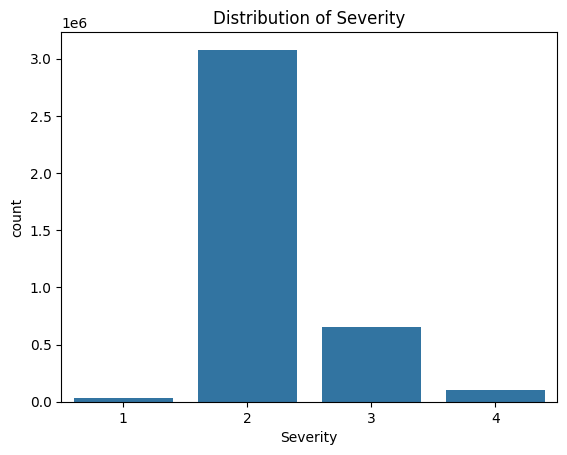

In [14]:
#plotting the final class
sns.countplot(x = df['Severity'])
plt.title('Distribution of Severity')

# Handling missing values

In [15]:
#checking missing values
df.isna().sum()

,0
ID,0
Source,0
Severity,0
Start_Time,0
End_Time,0
Start_Lat,0
Start_Lng,0
End_Lat,1701388
End_Lng,1701388
Distance(mi),0


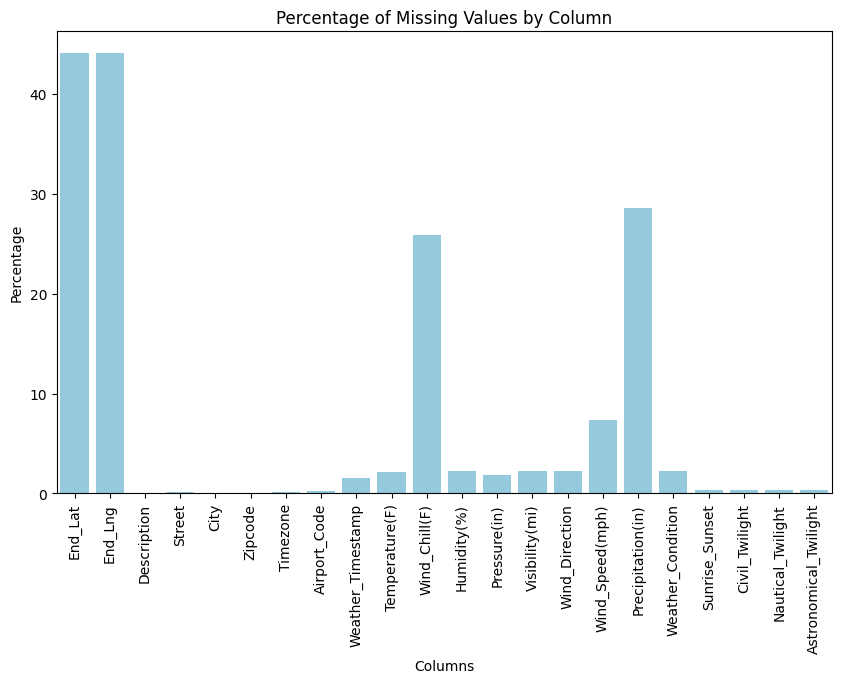

In [16]:
missing_percentages = df.isnull().mean() * 100
missing_percentages = missing_percentages[missing_percentages > 0]  # Only show columns with missing values

# Convert to DataFrame for seaborn plotting
missing_df = missing_percentages.reset_index()
missing_df.columns = ['Column', 'Missing Percentage']

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Column', y='Missing Percentage', data=missing_df, color='skyblue')
plt.title('Percentage of Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Percentage')
plt.xticks(rotation=90)
plt.show()

In [17]:
df = df.drop(columns=['End_Lat', 'End_Lng'])

# Data Visualization

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3864197 entries, 75721 to 7707750
Data columns (total 44 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   Distance(mi)           float64
 8   Description            object 
 9   Street                 object 
 10  City                   object 
 11  County                 object 
 12  State                  object 
 13  Zipcode                object 
 14  Country                object 
 15  Timezone               object 
 16  Airport_Code           object 
 17  Weather_Timestamp      object 
 18  Temperature(F)         float64
 19  Wind_Chill(F)          float64
 20  Humidity(%)            float64
 21  Pressure(in)           float64
 22  Visibility(mi)     

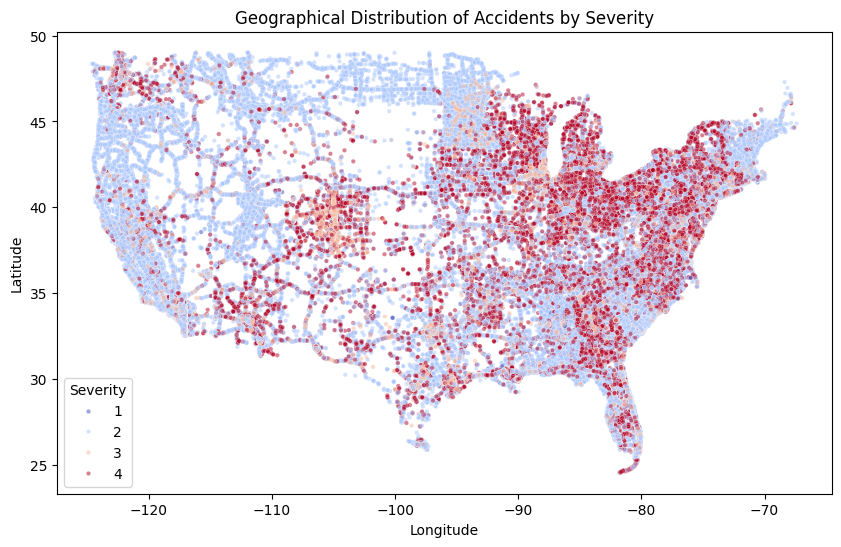

In [19]:
#plotting relationship between Number_of_casualties and Number_of_vehicles_involved

plt.figure(figsize=(10, 6))
# Using a small alpha (transparency) because this dataset usually has a massive number of rows
sns.scatterplot(
    x=df['Start_Lng'],
    y=df['Start_Lat'],
    hue=df['Severity'],
    palette='coolwarm',
    s=10,
    alpha=0.5
)

plt.title('Geographical Distribution of Accidents by Severity')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [20]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County',
       'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [21]:
duplicates = df[df.duplicated()]
print(len(duplicates))

0


# Airport Code

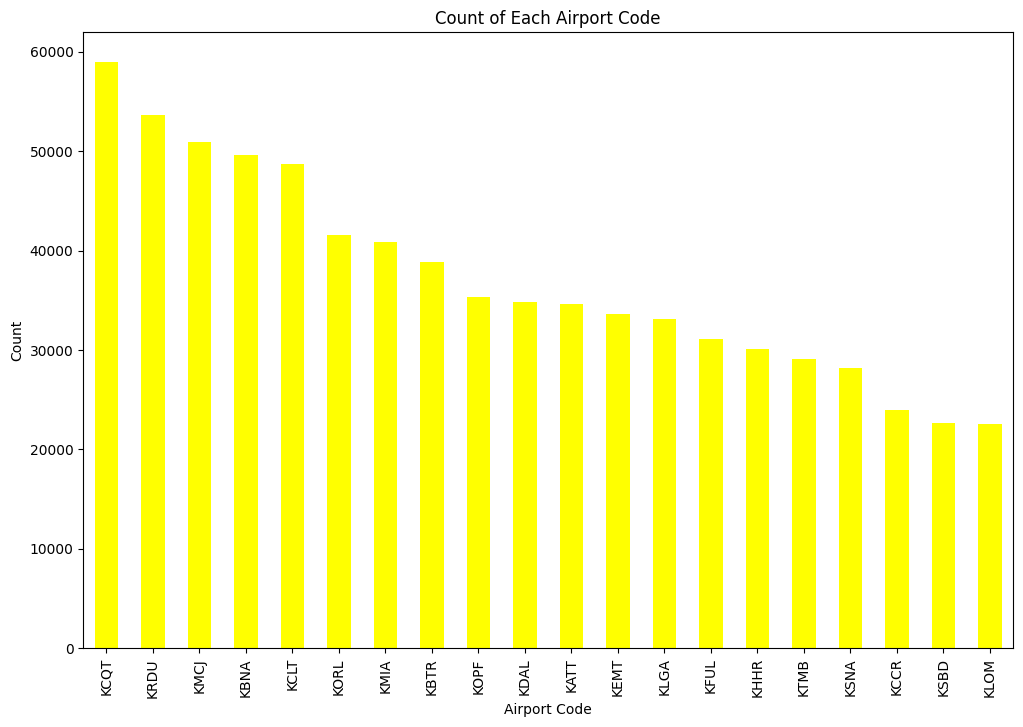

In [22]:
top_20_airport_codes = df['Airport_Code'].value_counts().head(20)
plt.figure(figsize=(12, 8))
top_20_airport_codes.plot(kind='bar', color='yellow')
plt.title('Count of Each Airport Code')
plt.xlabel('Airport Code')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate x-axis labels if needed
plt.show()

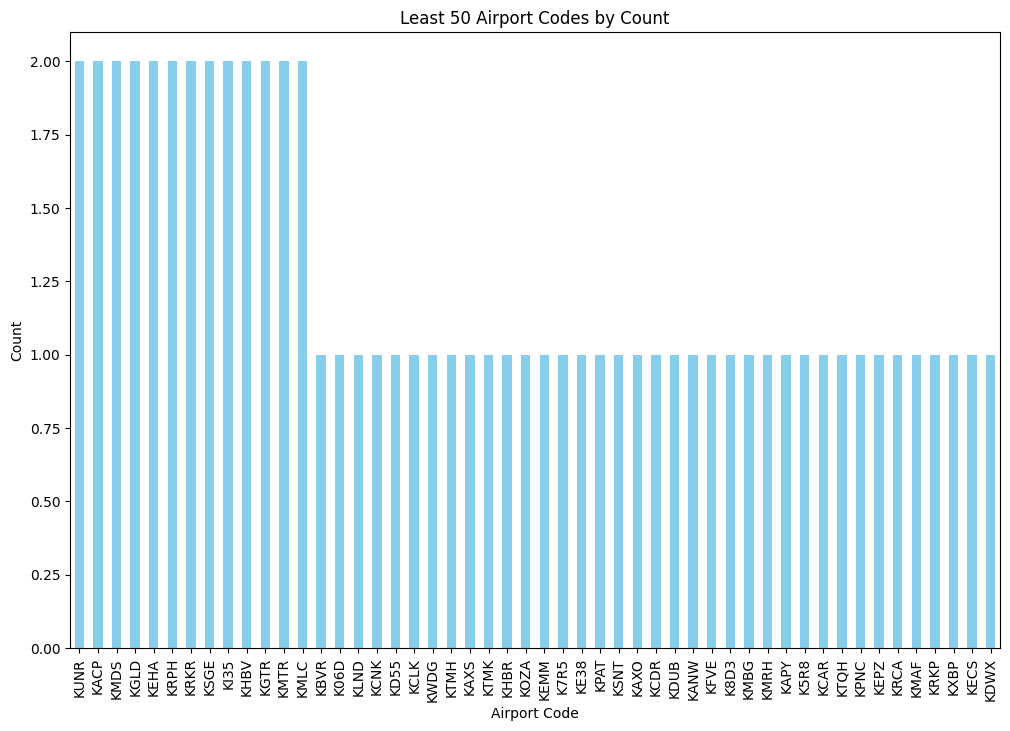

In [23]:
least_50_airport_codes = df['Airport_Code'].value_counts().tail(50)
plt.figure(figsize=(12, 8))
least_50_airport_codes.plot(kind='bar', color='skyblue')
plt.title('Least 50 Airport Codes by Count')
plt.xlabel('Airport Code')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.show()

In [24]:
df['City']

,City
75721,Los Angeles
80184,Norco
19864,Davis
76699,Riverside
92991,Gardena
...,...
7709640,Memphis
7719435,Buffalo
7722881,Bedford
7721775,Happy Valley


In [25]:
city_counts = df['City'].value_counts()
print(city_counts)
print(len(city_counts))

City
Miami            93709
Houston          84696
Los Angeles      77951
Charlotte        69390
Dallas           65448
                 ...  
Upper Jay            1
Olmstedville         1
Fort Jennings        1
Chase                1
Codyville Plt        1
Name: count, Length: 12869, dtype: int64
12869


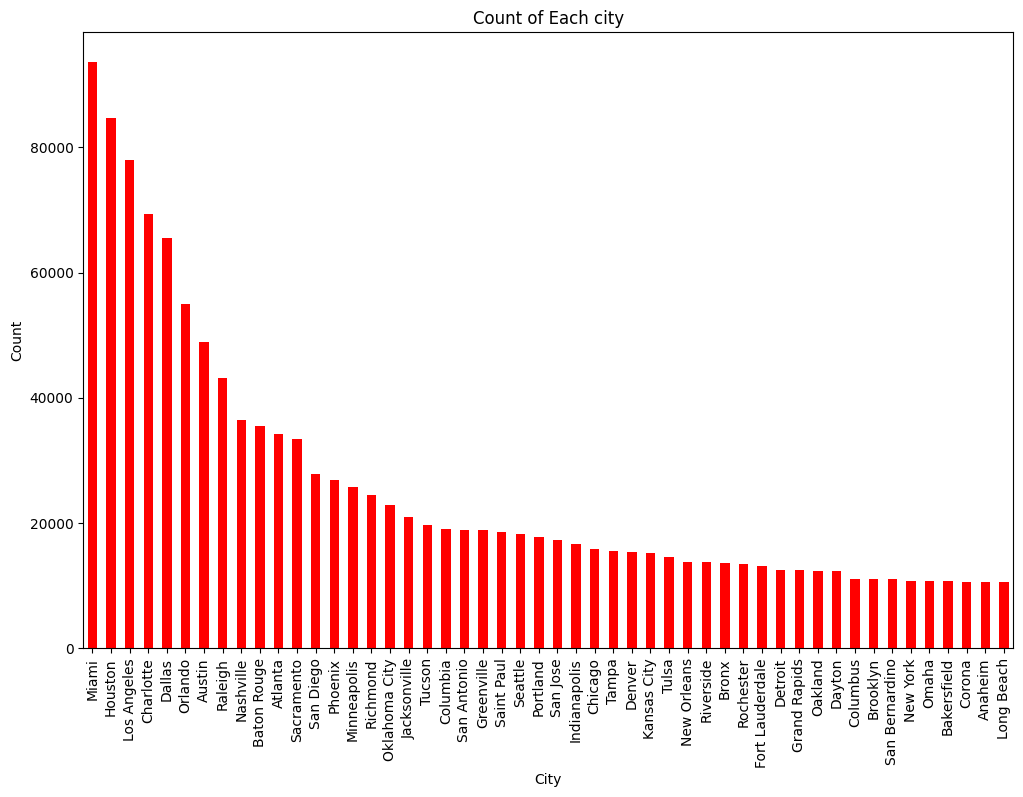

In [26]:
top_50_cities = df['City'].value_counts().head(50)
plt.figure(figsize=(12, 8))
top_50_cities.plot(kind='bar', color='red')
plt.title('Count of Each city')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate x-axis labels if needed
plt.show()

In [27]:
# Assuming df is your DataFrame
is_new_york_present = (df['City'] == 'New York').any()

print(" 'New York' present in city column?", is_new_york_present)

 'New York' present in city column? True


In [28]:
new_york_accidents = df[df['City'] == 'New York']
print(new_york_accidents.shape)

(10755, 44)


In [29]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County',
       'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [30]:
print(df['Country'].unique())

['US']


# state

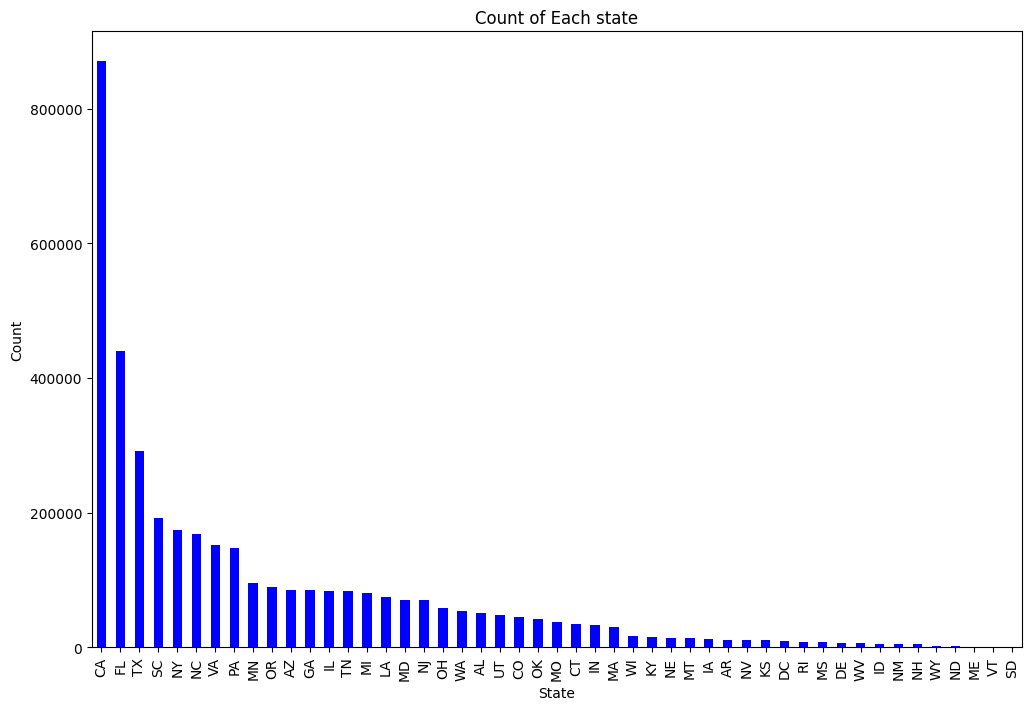

In [31]:
top_50_state = df['State'].value_counts().head(50)
plt.figure(figsize=(12, 8))
top_50_state.plot(kind='bar', color='blue')
plt.title('Count of Each state')
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate x-axis labels if needed
plt.show()

In [32]:
df['City_State'] = df['City'] + ', ' + df['State']

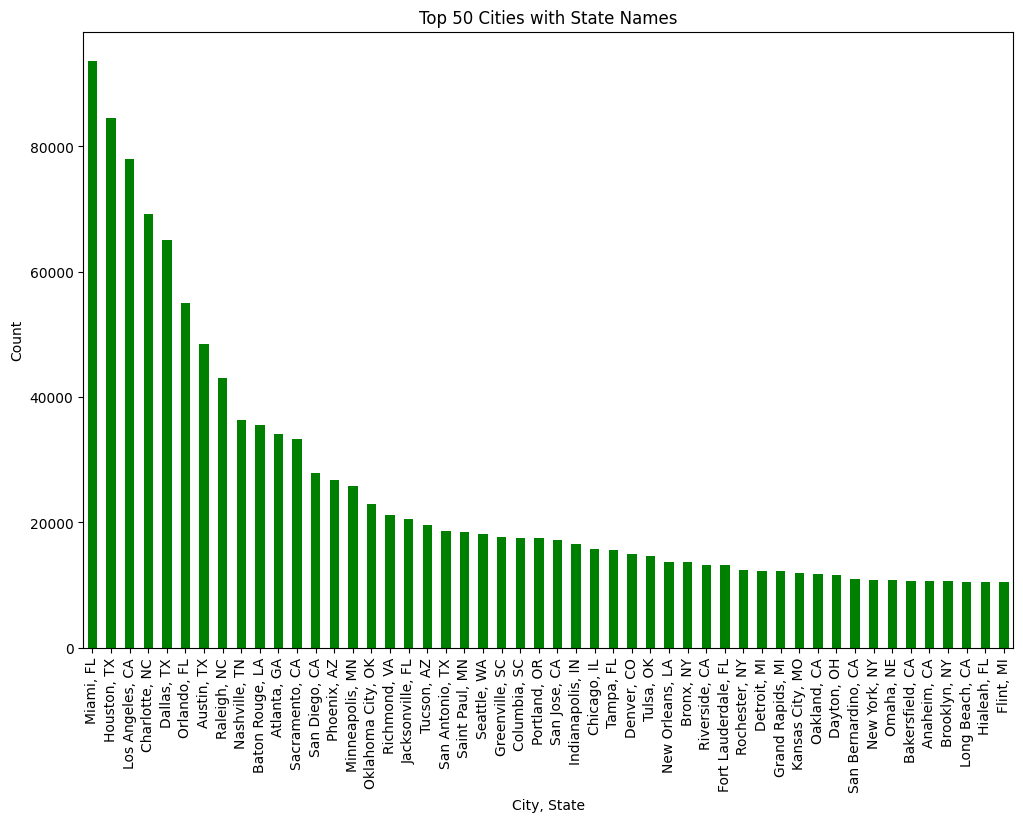

In [33]:
top_50_cities = df['City_State'].value_counts().head(50)
plt.figure(figsize=(12, 8))
top_50_cities.plot(kind='bar', color='green')
plt.title('Top 50 Cities with State Names')
plt.xlabel('City, State')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.show()

# street

In [34]:
top_5_cities = df['City'].value_counts().head(5)
top_5_cities_list = top_5_cities.index
top_5_city_data = df[df['City'].isin(top_5_cities_list)]
street_city_counts = top_5_city_data.groupby(['City', 'Street']).size().reset_index(name='Count')
print(street_city_counts)

            City                    Street  Count
0      Charlotte                  Abbey Pl      2
1      Charlotte             Abbotswood Dr      1
2      Charlotte               Abelwood Rd      1
3      Charlotte             Acorn Oaks Rd      1
4      Charlotte                  Acorn St      1
...          ...                       ...    ...
22632      Miami           W Okeechobee Rd    143
22633      Miami           W Old Cutler Rd      1
22634      Miami                Walsh Blvd      1
22635      Miami             Wilmington St      1
22636      Miami  Woodlawn Park Cemetary S      1

[22637 rows x 3 columns]


In [35]:
# top five street per city
top_5_streets_per_city = street_city_counts.groupby('City').apply(lambda x: x.nlargest(5, 'Count')).reset_index(drop=True)
print(top_5_streets_per_city)

           City               Street  Count
0     Charlotte               I-77 N   1517
1     Charlotte               I-77 S   1252
2     Charlotte           S Tryon St   1186
3     Charlotte  E Independence Blvd   1136
4     Charlotte               I-85 S   1056
5        Dallas              I-635 W   2926
6        Dallas              I-35E N   2359
7        Dallas              US-75 S   1554
8        Dallas              I-35E S   1402
9        Dallas              I-635 E   1382
10      Houston               I-45 N   3559
11      Houston               I-45 S   1946
12      Houston               I-10 W   1378
13      Houston              I-610 E   1248
14      Houston              I-610 W   1232
15  Los Angeles               I-10 E   3702
16  Los Angeles               I-10 W   3639
17  Los Angeles   Golden State Fwy S   2881
18  Los Angeles              I-405 N   2717
19  Los Angeles         Harbor Fwy N   2669
20        Miami               I-95 S   5063
21        Miami               I-

In [36]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County',
       'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'City_State'],
      dtype='object')

# starting Time

In [37]:
df['Start_Time']

,Start_Time
75721,2016-11-28 16:23:04
80184,2016-09-28 12:33:15
19864,2016-09-13 20:16:23
76699,2016-09-13 10:07:38
92991,2016-08-27 17:56:49
...,...
7709640,2019-07-15 11:59:30
7719435,2019-08-05 17:20:45
7722881,2019-08-12 15:50:29
7721775,2019-08-08 22:48:06


In [38]:
# Find rows with extra data in the 'Start_Time' column
problem_rows = df[df['Start_Time'].str.contains('\.', regex=True)]
print(problem_rows)

                ID   Source  Severity                     Start_Time  \
3684004  A-3711556  Source1         2  2022-10-12 09:52:24.000000000   
3650074  A-3664520  Source1         2  2023-03-25 15:24:00.000000000   
3642141  A-3652714  Source1         2  2023-03-31 14:49:00.000000000   
3641331  A-3651506  Source1         2  2023-03-28 13:40:47.000000000   
3684936  A-3712496  Source1         2  2022-09-29 18:33:00.000000000   
...            ...      ...       ...                            ...   
6831929  A-6881110  Source1         2  2020-11-04 18:51:00.000000000   
6830517  A-6879694  Source1         2  2020-09-11 15:41:50.000000000   
6830667  A-6879844  Source1         2  2020-09-28 00:45:00.000000000   
6832239  A-6881420  Source1         2  2020-12-11 07:01:00.000000000   
6833072  A-6882257  Source1         2  2020-09-17 21:25:00.000000000   

                              End_Time  Start_Lat   Start_Lng  Distance(mi)  \
3684004  2022-10-12 10:16:59.000000000  26.556711  -81.9

In [39]:
df['Start_Time'] = df['Start_Time'].str.replace(r'\.\d+$', '', regex=True)

In [40]:
problem_rows = df[df['Start_Time'].str.contains('\.', regex=True)]
print(problem_rows)

Empty DataFrame
Columns: [ID, Source, Severity, Start_Time, End_Time, Start_Lat, Start_Lng, Distance(mi), Description, Street, City, County, State, Zipcode, Country, Timezone, Airport_Code, Weather_Timestamp, Temperature(F), Wind_Chill(F), Humidity(%), Pressure(in), Visibility(mi), Wind_Direction, Wind_Speed(mph), Precipitation(in), Weather_Condition, Amenity, Bump, Crossing, Give_Way, Junction, No_Exit, Railway, Roundabout, Station, Stop, Traffic_Calming, Traffic_Signal, Turning_Loop, Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Astronomical_Twilight, City_State]
Index: []

[0 rows x 45 columns]


In [41]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

In [42]:
df['Start_Time']

,Start_Time
75721,2016-11-28 16:23:04
80184,2016-09-28 12:33:15
19864,2016-09-13 20:16:23
76699,2016-09-13 10:07:38
92991,2016-08-27 17:56:49
...,...
7709640,2019-07-15 11:59:30
7719435,2019-08-05 17:20:45
7722881,2019-08-12 15:50:29
7721775,2019-08-08 22:48:06


In [43]:
df['Hour'] = df['Start_Time'].dt.hour
df['Hour']

,Hour
75721,16
80184,12
19864,20
76699,10
92991,17
...,...
7709640,11
7719435,17
7722881,15
7721775,22


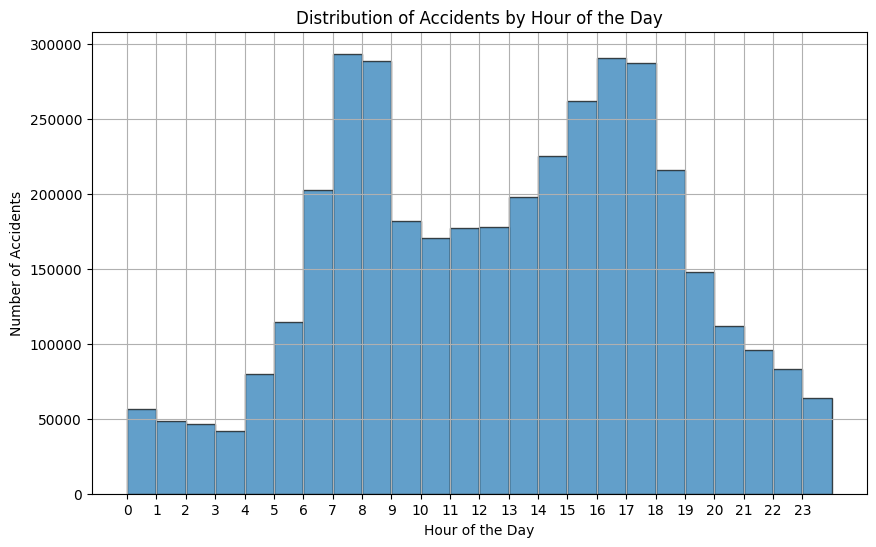

In [44]:
# Plot histogram for the 'Hour' column
plt.figure(figsize=(10, 6))
plt.hist(df['Hour'], bins=range(0, 25), edgecolor='black', alpha=0.7)
plt.title('Distribution of Accidents by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24))  # Show ticks for each hour
plt.grid(True)
plt.show()

In [45]:
df['Day_Name'] = df['Start_Time'].dt.day_name()
df['Day_Name']

,Day_Name
75721,Monday
80184,Wednesday
19864,Tuesday
76699,Tuesday
92991,Saturday
...,...
7709640,Monday
7719435,Monday
7722881,Monday
7721775,Thursday


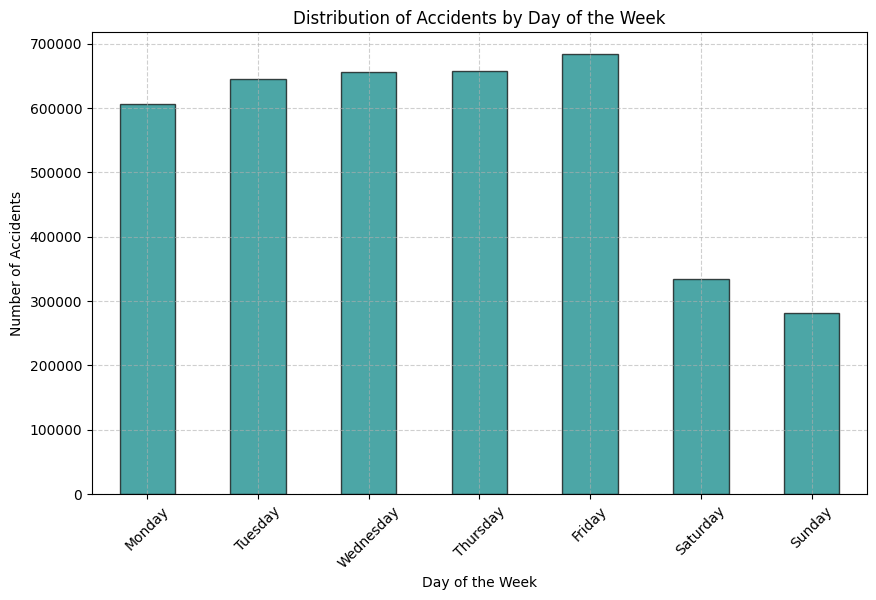

In [46]:
# Plot histogram for the 'Day_Name' column
plt.figure(figsize=(10, 6))
df['Day_Name'].value_counts().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).plot(kind='bar', color='Teal', edgecolor='black', alpha=0.7)
plt.title('Distribution of Accidents by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

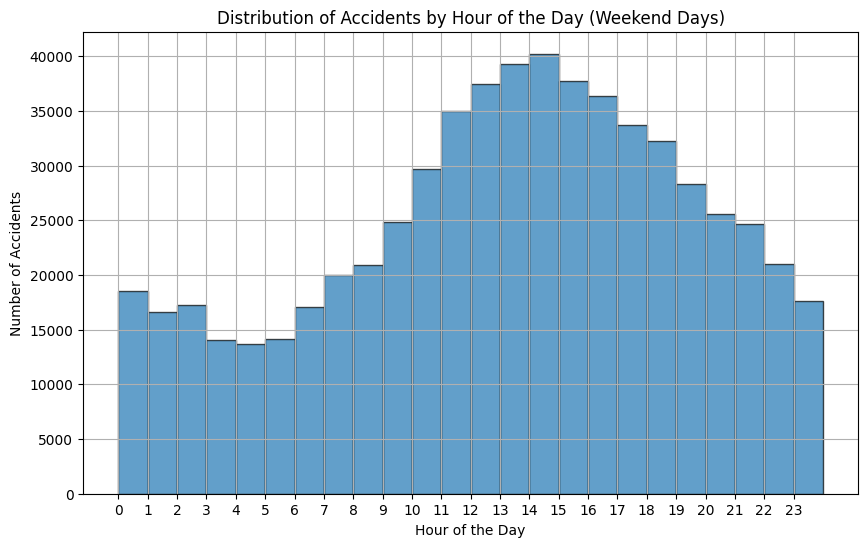

In [47]:
# Filter for weekend days (Saturday and Sunday)
weekend_days = ['Saturday', 'Sunday']
df_weekend = df[df['Day_Name'].isin(weekend_days)]

# Plot histogram for the 'Hour' column for weekend days
plt.figure(figsize=(10, 6))
plt.hist(df_weekend['Hour'], bins=range(0, 25), edgecolor='black', alpha=0.7)
plt.title('Distribution of Accidents by Hour of the Day (Weekend Days)')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24))  # Show ticks for each hour
plt.grid(True)
plt.show()

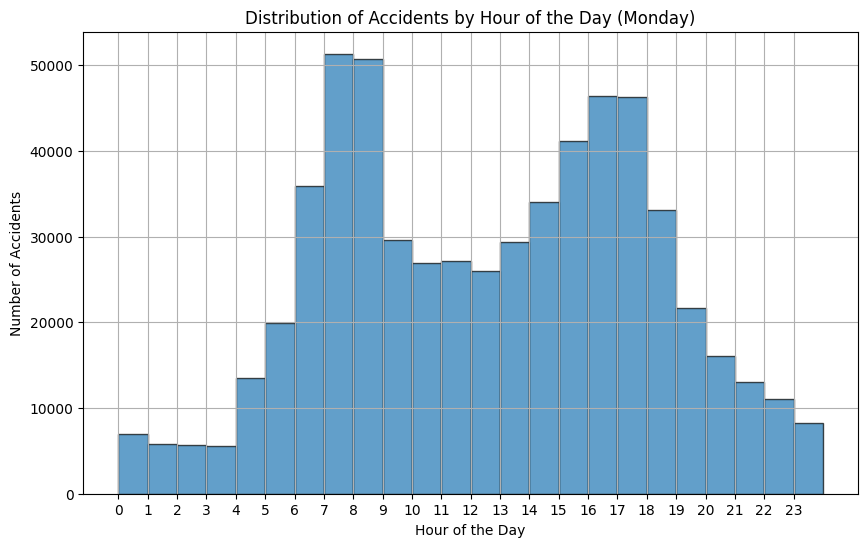

In [48]:
df_monday = df[df['Day_Name'] == 'Monday']

# Plot histogram for the 'Hour' column for Monday
plt.figure(figsize=(10, 6))
plt.hist(df_monday['Hour'], bins=range(0, 25), edgecolor='black', alpha=0.7)
plt.title('Distribution of Accidents by Hour of the Day (Monday)')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24))  # Show ticks for each hour
plt.grid(True)
plt.show()

In [49]:
df['Month'] = df['Start_Time'].dt.month
df['Month']

,Month
75721,11
80184,9
19864,9
76699,9
92991,8
...,...
7709640,7
7719435,8
7722881,8
7721775,8


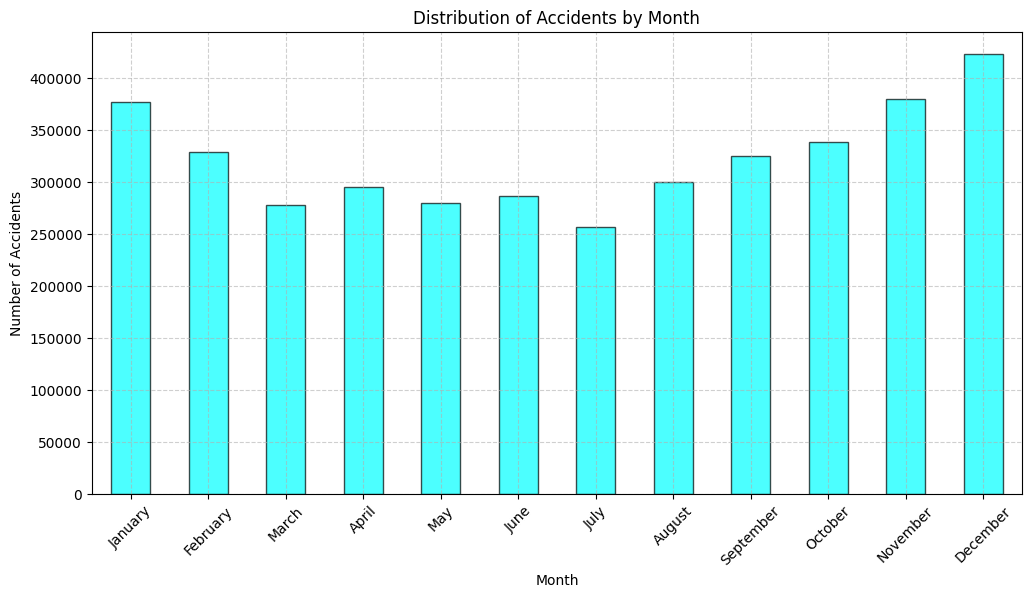

In [50]:
# Plot histogram for the 'Month' column
plt.figure(figsize=(12, 6))
df['Month'].value_counts().reindex(range(1, 13)).plot(kind='bar', color='Cyan', edgecolor='black', alpha=0.7)
plt.title('Distribution of Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.xticks(ticks=range(12), labels=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

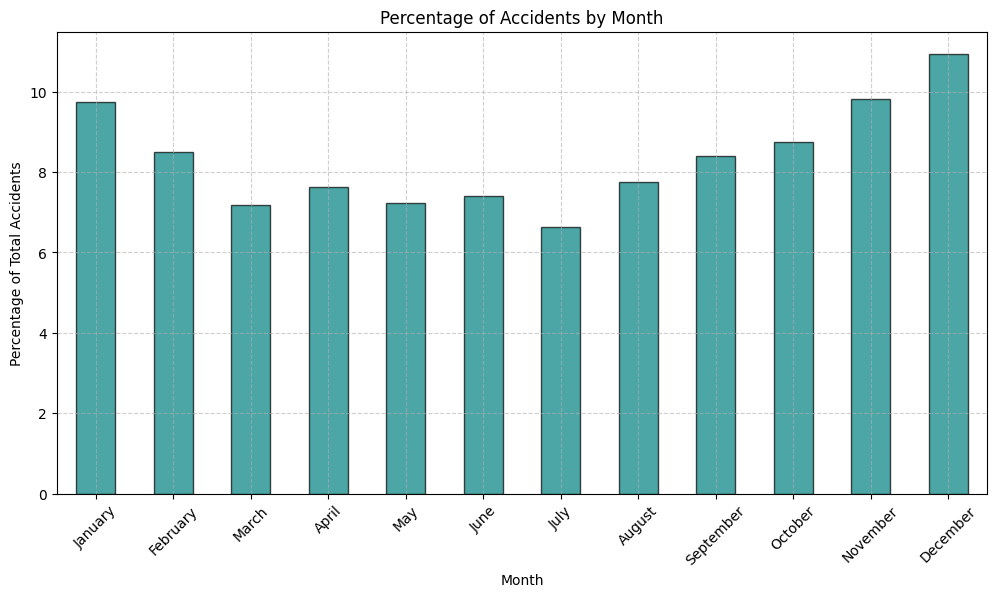

In [51]:
# Calculate percentage of accidents per month
month_counts = df['Month'].value_counts().reindex(range(1, 13), fill_value=0)
month_percentages = (month_counts / month_counts.sum()) * 100

# Plot histogram for the 'Month' column as percentages
plt.figure(figsize=(12, 6))
month_percentages.plot(kind='bar', color='Teal', edgecolor='black', alpha=0.7)
plt.title('Percentage of Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Accidents')
plt.xticks(ticks=range(12), labels=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

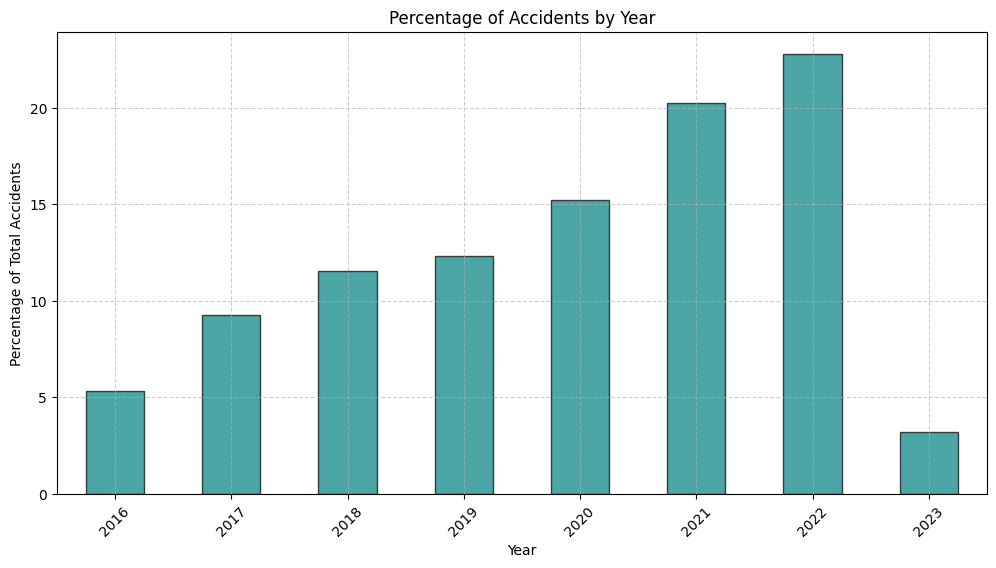

In [52]:
# Extract the year
df['Year'] = df['Start_Time'].dt.year

# Calculate the number of accidents per year
year_counts = df['Year'].value_counts().sort_index()

# Calculate percentages if needed
year_percentages = (year_counts / year_counts.sum()) * 100

# Plot histogram for the 'Year' column
plt.figure(figsize=(12, 6))
year_percentages.plot(kind='bar', color='Teal', edgecolor='black', alpha=0.7)
plt.title('Percentage of Accidents by Year')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Accidents')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

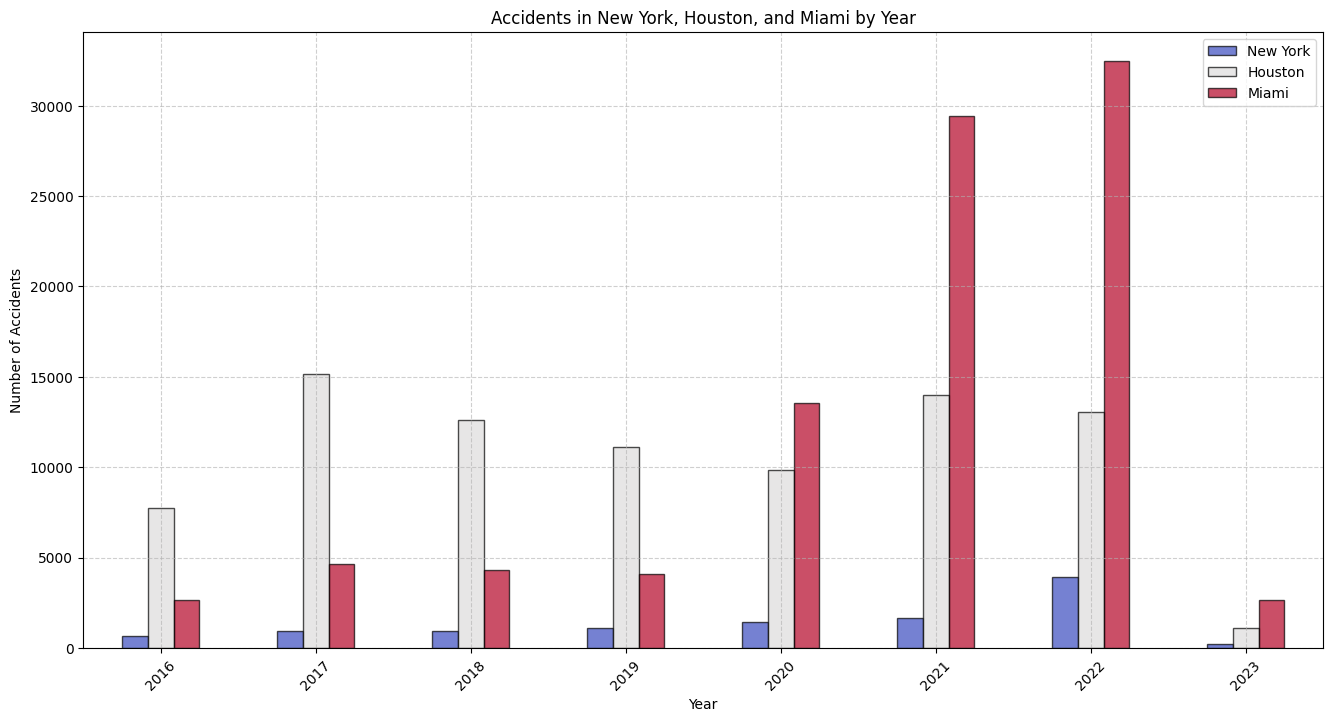

In [53]:
# Filter rows for New York, Houston, and Miami
ny_df = df[df['City'] == 'New York']
hou_df = df[df['City'] == 'Houston']
mia_df = df[df['City'] == 'Miami']

# Extract the year
ny_df['Year'] = ny_df['Start_Time'].dt.year
hou_df['Year'] = hou_df['Start_Time'].dt.year
mia_df['Year'] = mia_df['Start_Time'].dt.year

# Count occurrences by year for all cities
ny_year_counts = ny_df['Year'].value_counts().sort_index()
hou_year_counts = hou_df['Year'].value_counts().sort_index()
mia_year_counts = mia_df['Year'].value_counts().sort_index()

# Combine the counts into a single DataFrame
comparison_df = pd.DataFrame({
    'New York': ny_year_counts,
    'Houston': hou_year_counts,
    'Miami': mia_year_counts
}).fillna(0)  # Fill NaN values with 0 for years present in one city but not the others

# Plot the comparison
comparison_df.plot(kind='bar', figsize=(16, 8), colormap='coolwarm', edgecolor='black', alpha=0.7)
plt.title('Accidents in New York, Houston, and Miami by Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# End Time

In [54]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County',
       'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'City_State', 'Hour', 'Day_Name', 'Month',
       'Year'],
      dtype='object')

In [55]:
df['End_Time'] = df['End_Time'].str.replace(r'\.\d+$', '', regex=True)
df['End_Time'] = pd.to_datetime(df['End_Time'])

In [56]:
# Calculate the duration between Start_Time and End_Time
df['Duration'] = df['End_Time'] - df['Start_Time']

In [57]:
df['Duration']

,Duration
75721,0 days 00:44:35
80184,0 days 00:29:42
19864,0 days 00:30:00
76699,0 days 00:30:00
92991,0 days 00:30:00
...,...
7709640,0 days 00:28:56
7719435,0 days 00:29:27
7722881,0 days 00:29:24
7721775,0 days 04:00:00


In [58]:
# Extract duration in different units (optional)
df['Duration_Seconds'] = df['Duration'].dt.total_seconds()
df['Duration_Minutes'] = df['Duration_Seconds'] / 60
df['Duration_Hours'] = df['Duration_Seconds'] / 3600

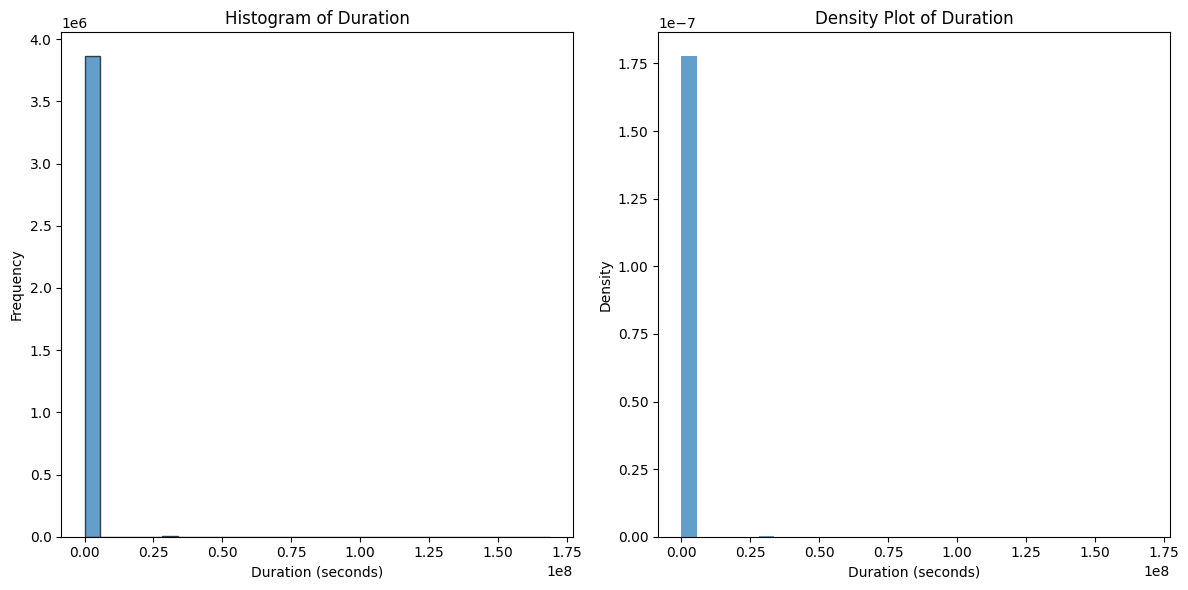

In [59]:
# Plot distribution of duration
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['Duration_Seconds'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of Duration')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')

# Density Plot (using seaborn)
plt.subplot(1, 2, 2)
if 'seaborn' in locals():
    sns.kdeplot(df['Duration_Seconds'], fill=True)
else:
    plt.hist(df['Duration_Seconds'], bins=30, density=True, alpha=0.7)
    plt.title('Density Plot of Duration')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Density')

plt.title('Density Plot of Duration')
plt.xlabel('Duration (seconds)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [60]:
df['Duration_Seconds']

,Duration_Seconds
75721,2675.0
80184,1782.0
19864,1800.0
76699,1800.0
92991,1800.0
...,...
7709640,1736.0
7719435,1767.0
7722881,1764.0
7721775,14400.0


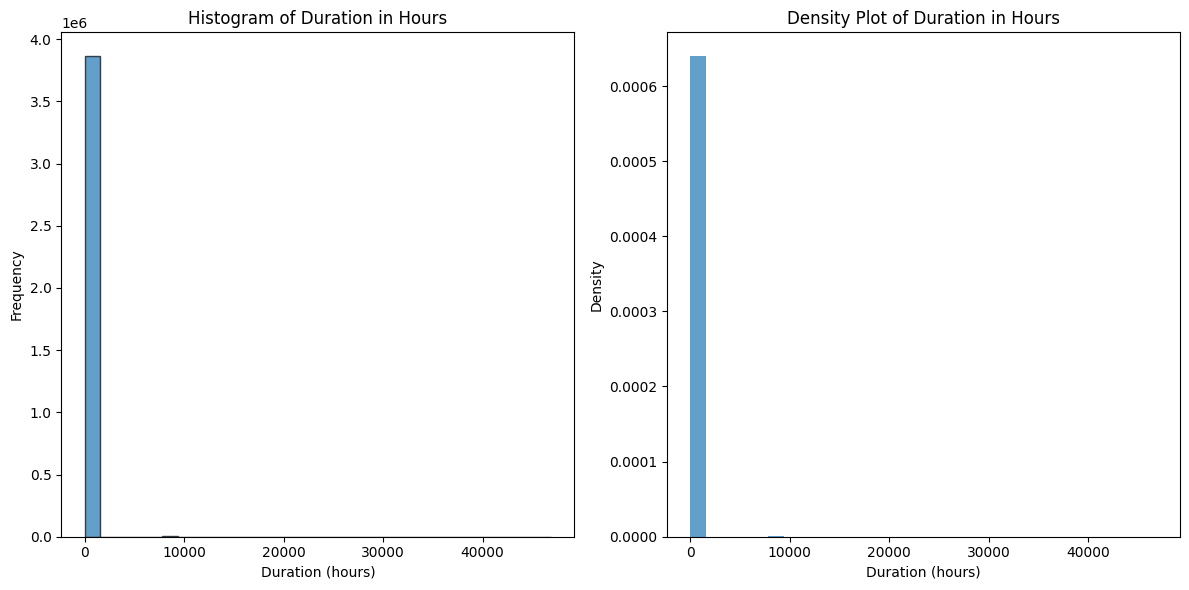

In [61]:
# Plot distribution of duration in hours
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['Duration_Hours'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of Duration in Hours')
plt.xlabel('Duration (hours)')
plt.ylabel('Frequency')

# Density Plot (using seaborn)
plt.subplot(1, 2, 2)
if 'seaborn' in locals():
    sns.kdeplot(df['Duration_Hours'], fill=True)
else:
    plt.hist(df['Duration_Hours'], bins=30, density=True, alpha=0.7)
    plt.title('Density Plot of Duration in Hours')
    plt.xlabel('Duration (hours)')
    plt.ylabel('Density')

plt.title('Density Plot of Duration in Hours')
plt.xlabel('Duration (hours)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

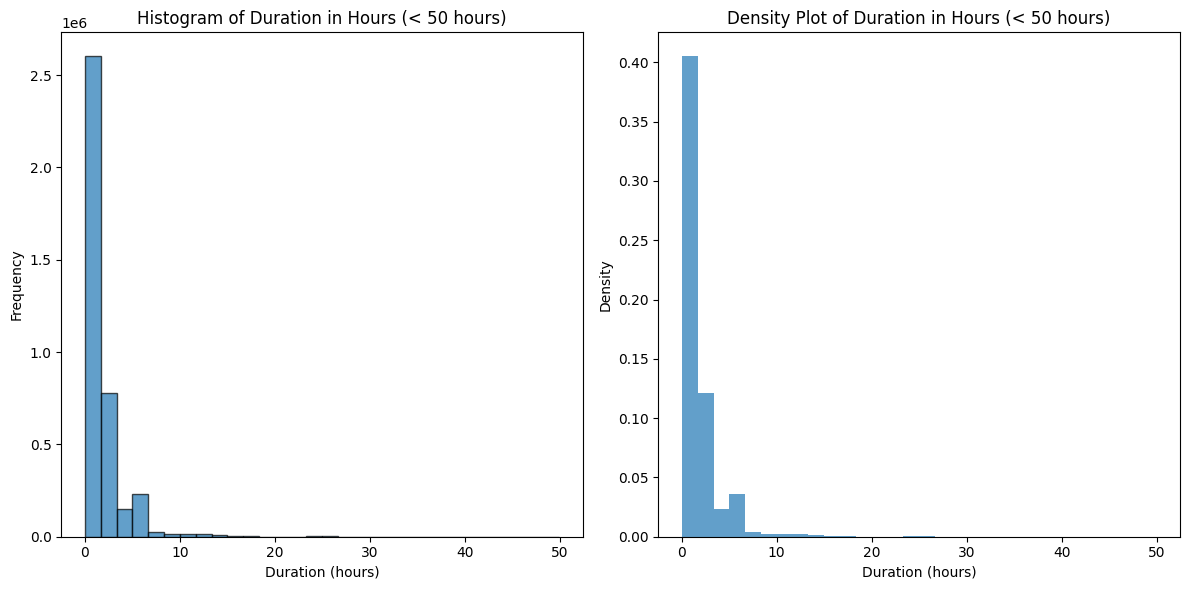

In [62]:
# Filter out durations that are less than 10,000 hours
filtered_df = df[df['Duration_Hours'] < 50]

# Plot distribution of duration in hours
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(filtered_df['Duration_Hours'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of Duration in Hours (< 50 hours)')
plt.xlabel('Duration (hours)')
plt.ylabel('Frequency')

# Density Plot (using seaborn)
plt.subplot(1, 2, 2)
if 'seaborn' in locals():
    sns.kdeplot(filtered_df['Duration_Hours'], fill=True)
else:
    plt.hist(filtered_df['Duration_Hours'], bins=30, density=True, alpha=0.7)
    plt.title('Density Plot of Duration in Hours (< 50 hours)')
    plt.xlabel('Duration (hours)')
    plt.ylabel('Density')

plt.title('Density Plot of Duration in Hours (< 50 hours)')
plt.xlabel('Duration (hours)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

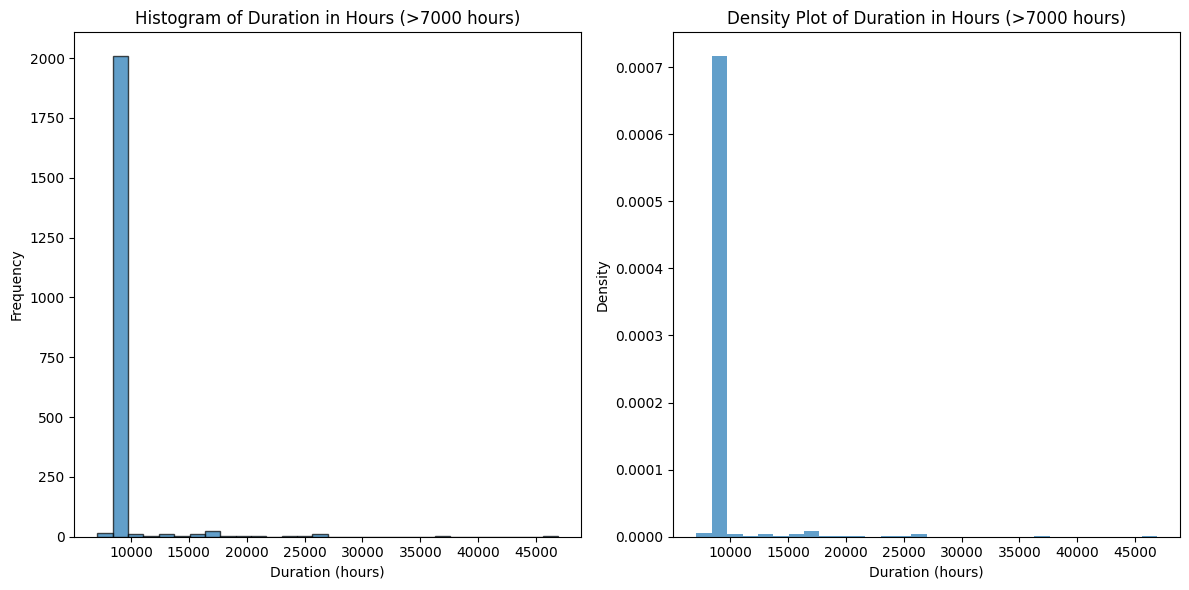

In [63]:
# Filter out durations that are less than 10,000 hours
filtered_df = df[df['Duration_Hours'] >7000]

# Plot distribution of duration in hours
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(filtered_df['Duration_Hours'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of Duration in Hours (>7000 hours)')
plt.xlabel('Duration (hours)')
plt.ylabel('Frequency')

# Density Plot (using seaborn)
plt.subplot(1, 2, 2)
if 'seaborn' in locals():
    sns.kdeplot(filtered_df['Duration_Hours'], fill=True)
else:
    plt.hist(filtered_df['Duration_Hours'], bins=30, density=True, alpha=0.7)
    plt.title('Density Plot of Duration in Hours (>7000 hours)')
    plt.xlabel('Duration (hours)')
    plt.ylabel('Density')

plt.title('Density Plot of Duration in Hours (>7000 hours)')
plt.xlabel('Duration (hours)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [64]:
# study the second type

In [65]:
# Filter out durations greater than 8,000 hours
filtered_df = df[df['Duration_Hours'] > 8000]

# Display the filtered DataFrame
print(filtered_df['Description'].iloc[90])

Incident on I-10 EB near ATCHAFALAYA RIVER Left lane blocked.


count    2101.000000
mean        1.416393
std         1.703282
min         0.000000
25%         0.326000
50%         0.807000
75%         1.855000
max        13.882000
Name: Distance(mi), dtype: float64


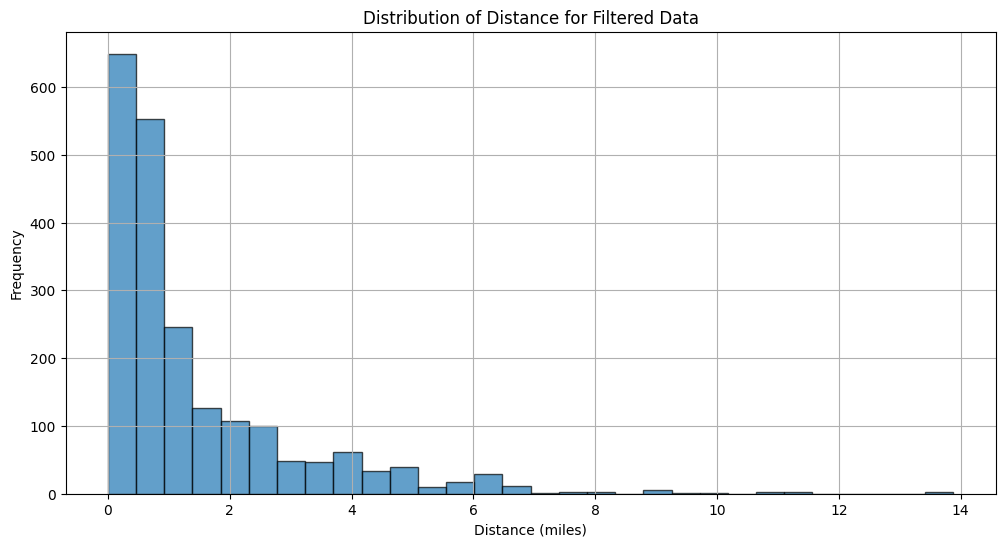

In [66]:
# Display basic statistics for the 'Distance(mi)' column
print(filtered_df['Distance(mi)'].describe())

# Plot histogram for the 'Distance(mi)' column
plt.figure(figsize=(12, 6))
plt.hist(filtered_df['Distance(mi)'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Distance for Filtered Data')
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

City_State
Baton Rouge, LA       299
New Orleans, LA       239
Shreveport, LA        159
Lake Charles, LA       81
Port Allen, LA         77
                     ... 
Prosperity, PA          1
Raleigh, NC             1
Wellington, NV          1
West Lafayette, IN      1
Cincinnati, OH          1
Name: count, Length: 152, dtype: int64


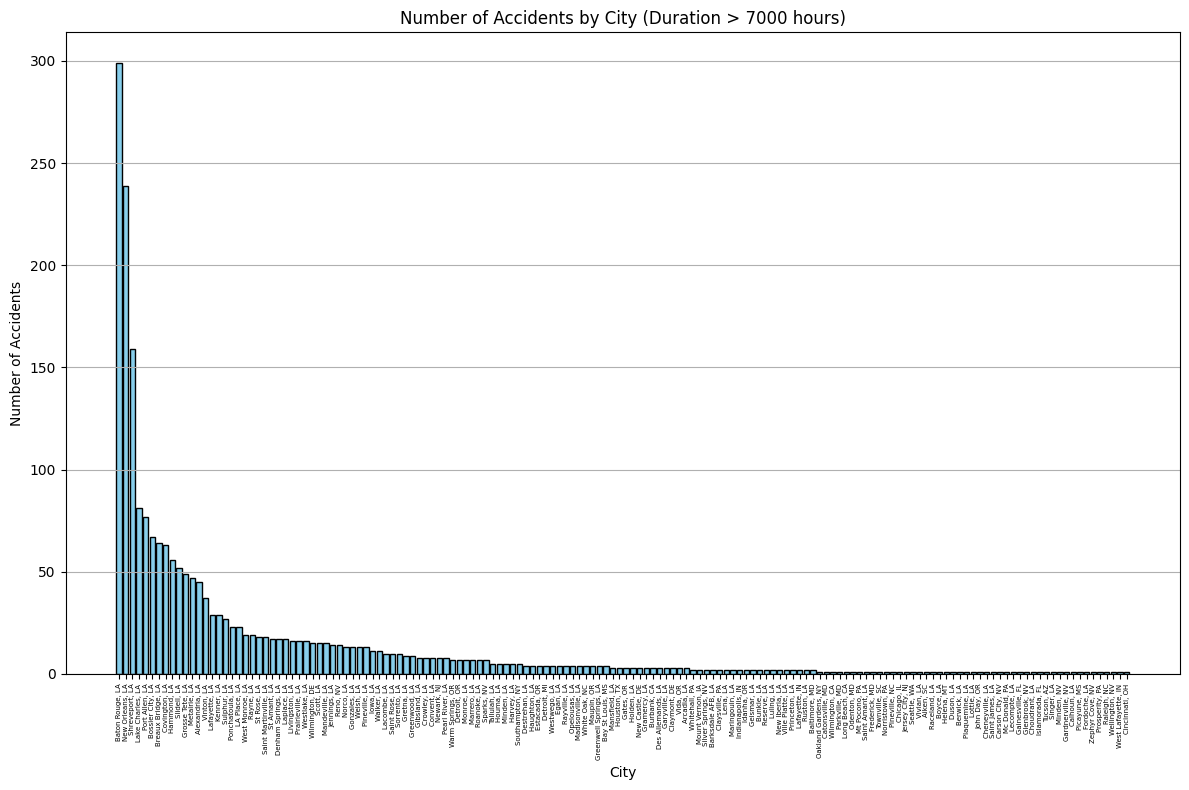

In [67]:
# Filter out durations greater than 7,000 hours
filtered_df = df[df['Duration_Hours'] > 7000]

# Count the number of accidents per city
city_counts = filtered_df['City_State'].value_counts()

# Print the city counts
print(city_counts)

# Plot the distribution of accidents by city
plt.figure(figsize=(12, 8))

# Bar plot
plt.bar(city_counts.index, city_counts.values, color='skyblue', edgecolor='black')
plt.title('Number of Accidents by City (Duration > 7000 hours)')
plt.xlabel('City')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xticks(fontsize=5)  # Adjust fontsize as needed
plt.grid(axis='y')

plt.tight_layout()
plt.show()

## study the first type

In [68]:

# Assuming you have already filtered your DataFrame
filtered_df = df[df['Duration_Hours'] < 50]

# Calculate the mean of the 'Duration_Hours' column
mean_duration = filtered_df['Duration_Hours'].mean()

print(f"Mean Duration (hours) for records with less than 50 hours: {mean_duration:.2f}")

Mean Duration (hours) for records with less than 50 hours: 1.88


count    3.858945e+06
mean     5.605611e-01
std      1.780342e+00
min      0.000000e+00
25%      0.000000e+00
50%      2.900000e-02
75%      4.630000e-01
max      3.365700e+02
Name: Distance(mi), dtype: float64


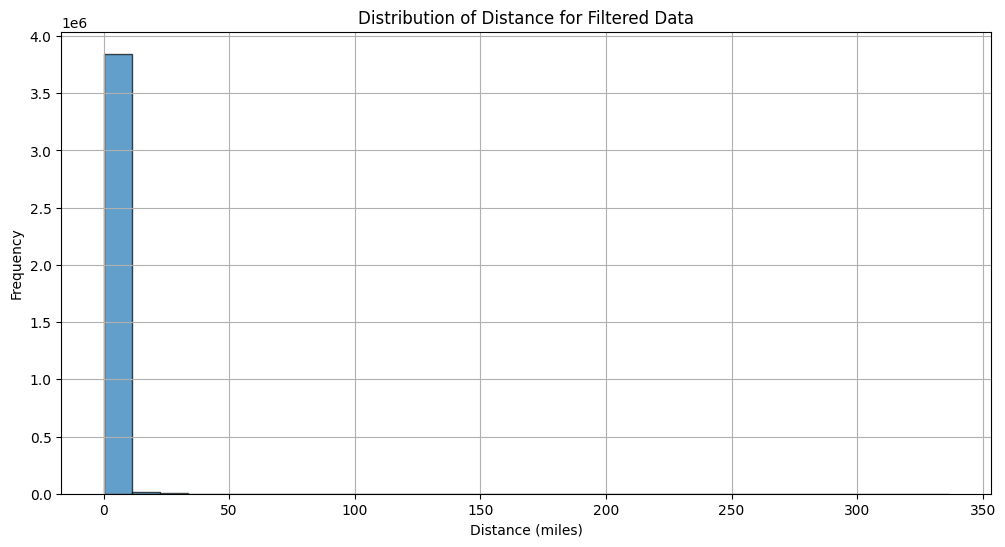

In [69]:
# Display basic statistics for the 'Distance(mi)' column
print(filtered_df['Distance(mi)'].describe())

# Plot histogram for the 'Distance(mi)' column
plt.figure(figsize=(12, 6))
plt.hist(filtered_df['Distance(mi)'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Distance for Filtered Data')
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [70]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County',
       'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'City_State', 'Hour', 'Day_Name', 'Month',
       'Year', 'Duration', 'Duration_Seconds', 'Duration_Minutes',
       'Duration_Hours'],
      dtype='object')

City_State
Miami, FL          93435
Houston, TX        84585
Los Angeles, CA    77901
Charlotte, NC      69229
Dallas, TX         65115
                   ...  
Pittston, ME           1
New Durham, NH         1
Russell, IA            1
Harbeson, DE           1
Crivitz, WI            1
Name: count, Length: 18874, dtype: int64


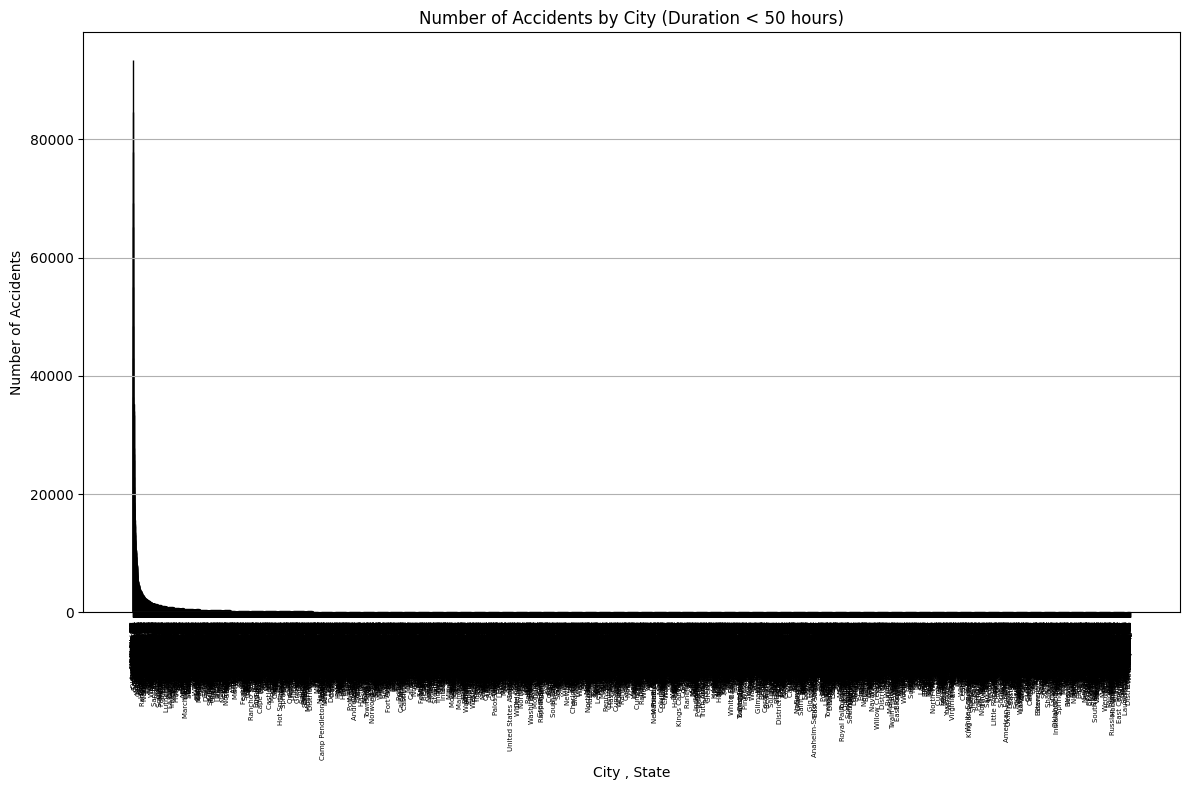

In [71]:
# Filter out durations greater than 7,000 hours
filtered_df = df[df['Duration_Hours'] < 50]

# Count the number of accidents per city
city_counts = filtered_df['City_State'].value_counts()

# Print the city counts
print(city_counts)

# Plot the distribution of accidents by city
plt.figure(figsize=(12, 8))

# Bar plot
plt.bar(city_counts.index, city_counts.values, color='skyblue', edgecolor='black')
plt.title('Number of Accidents by City (Duration < 50 hours)')
plt.xlabel('City , State')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xticks(fontsize=5)  # Adjust fontsize as needed
plt.grid(axis='y')

plt.tight_layout()
plt.show()

## Visibility(mi)

In [72]:

df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County',
       'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'City_State', 'Hour', 'Day_Name', 'Month',
       'Year', 'Duration', 'Duration_Seconds', 'Duration_Minutes',
       'Duration_Hours'],
      dtype='object')

In [73]:
df['Visibility(mi)'].describe()


,Visibility(mi)
count,3.775599e+06
mean,9.089656e+00
std,2.690469e+00
min,0.000000e+00
25%,1.000000e+01
50%,1.000000e+01
75%,1.000000e+01
max,1.200000e+02


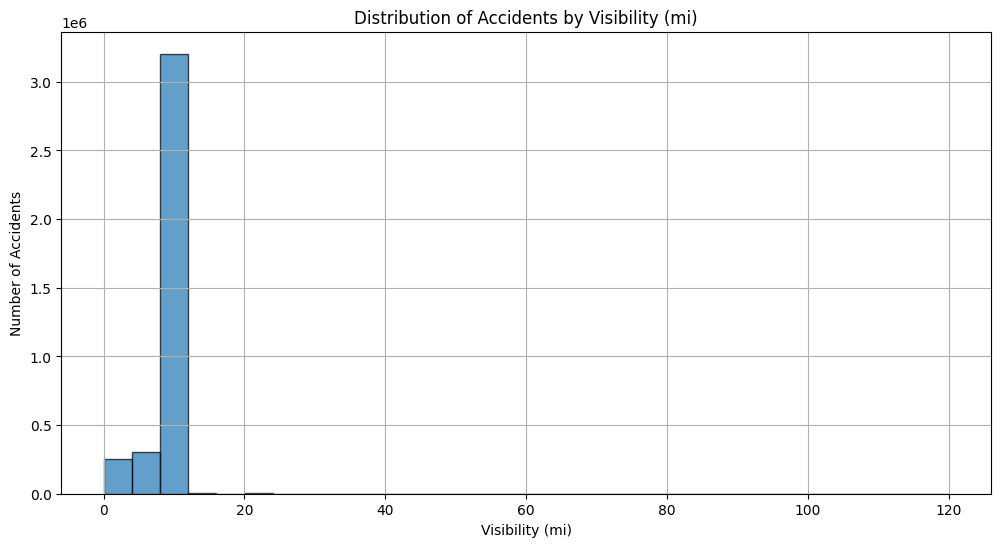

In [74]:

# Plot histogram for 'Visibility(mi)'
plt.figure(figsize=(12, 6))
plt.hist(df['Visibility(mi)'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Accidents by Visibility (mi)')
plt.xlabel('Visibility (mi)')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

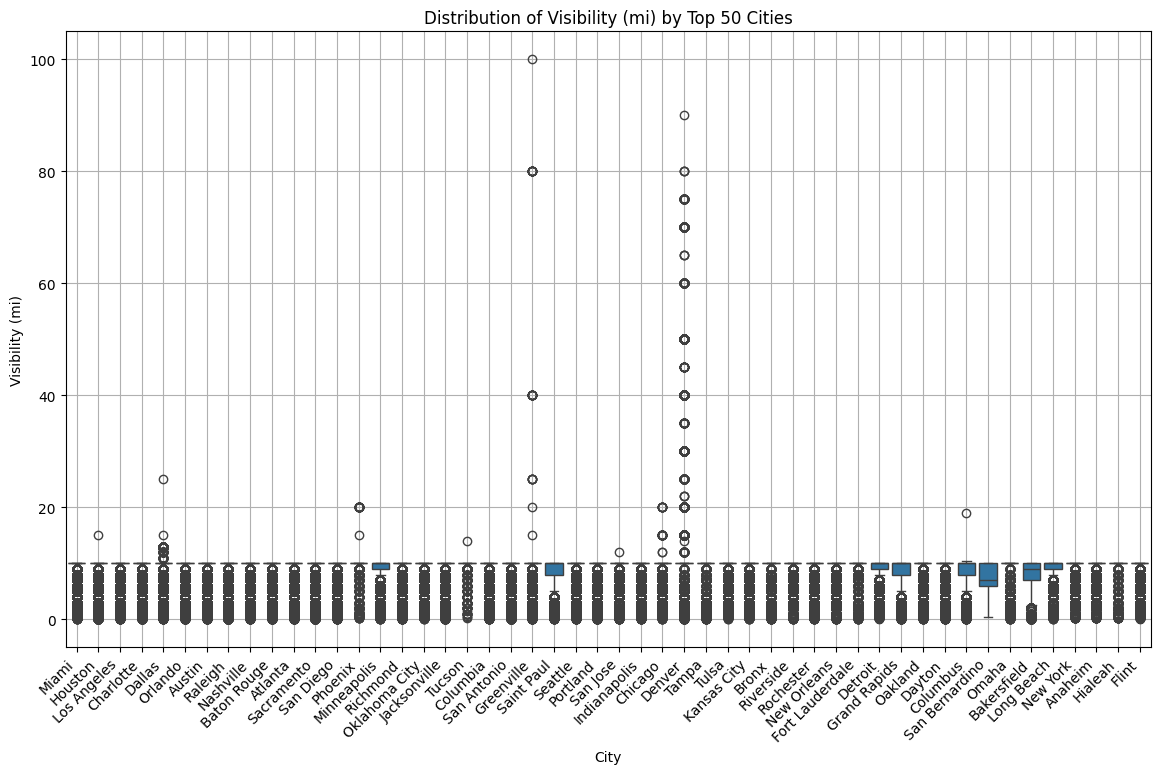

In [75]:
# Ensure 'Visibility(mi)' is numeric, convert if necessary
df['Visibility(mi)'] = pd.to_numeric(df['Visibility(mi)'], errors='coerce')

# Drop rows with NaN values in 'Visibility(mi)'
df_clean = df.dropna(subset=['Visibility(mi)'])

# Count accidents per city
city_accidents = df_clean['City'].value_counts()

# Identify top 50 cities with the most accidents
top_50_cities = city_accidents.head(50).index

# Filter the DataFrame to include only the top 50 cities
df_top_50 = df_clean[df_clean['City'].isin(top_50_cities)]

# Reorder cities by accident count
city_order = city_accidents.loc[top_50_cities].index

# Plot box plot for 'Visibility(mi)' by 'City' for top 50 cities sorted by accident count
plt.figure(figsize=(14, 8))
sns.boxplot(x='City', y='Visibility(mi)', data=df_top_50, order=city_order)
plt.title('Distribution of Visibility (mi) by Top 50 Cities')
plt.xlabel('City')
plt.ylabel('Visibility (mi)')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.xticks(fontsize=10)  # Adjust fontsize as needed
plt.grid(True)
plt.show()

### we remarque the the top 50 cities has almost the same distribution of visibility

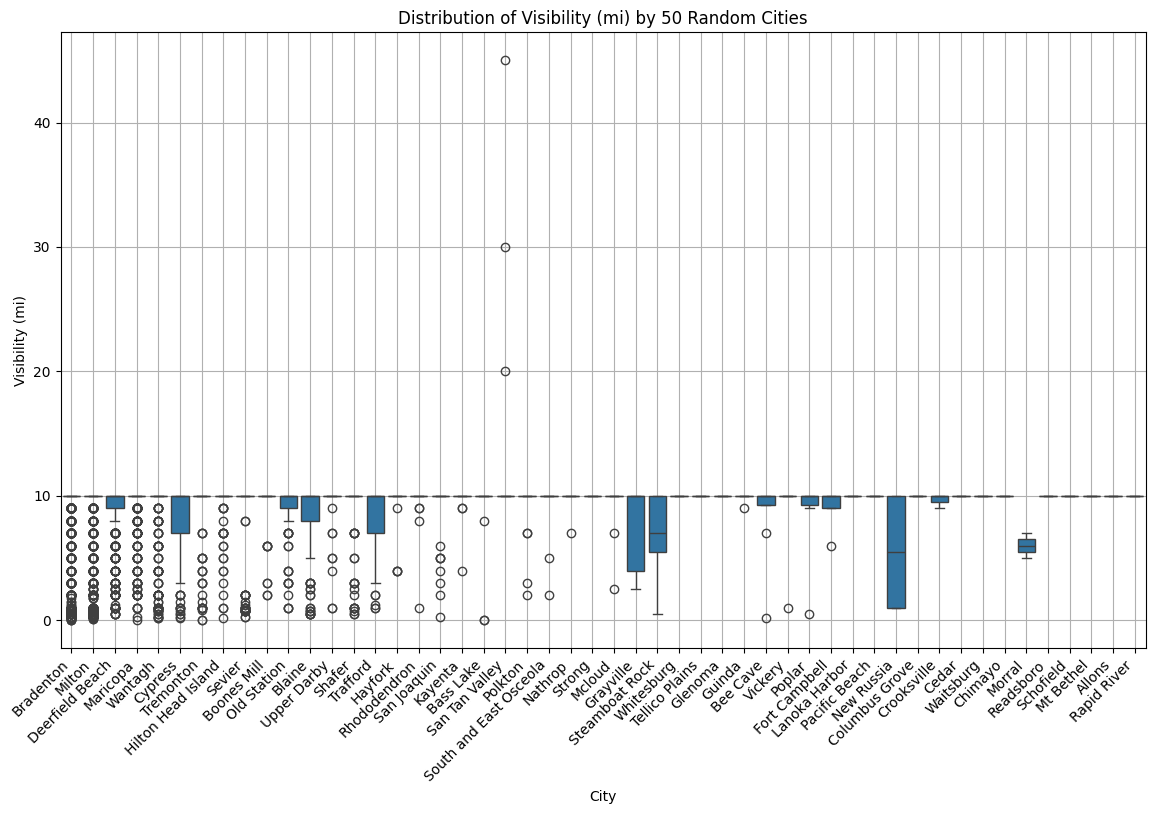

In [76]:

# Get unique cities
unique_cities = df_clean['City'].unique()


# Randomly sample 50 cities
random_cities = pd.Series(unique_cities).sample(n=50, random_state=62).tolist()

# Filter the DataFrame to include only the random cities
df_random_cities = df_clean[df_clean['City'].isin(random_cities)]

# Reorder cities by accident count for the random cities
city_order_random = df_random_cities['City'].value_counts().index

# Plot box plot for 'Visibility(mi)' by 'City' for random cities
plt.figure(figsize=(14, 8))
sns.boxplot(x='City', y='Visibility(mi)', data=df_random_cities, order=city_order_random)
plt.title('Distribution of Visibility (mi) by 50 Random Cities')
plt.xlabel('City')
plt.ylabel('Visibility (mi)')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.xticks(fontsize=10)  # Adjust fontsize as needed
plt.grid(True)
plt.show()

 ## 'Visibility(mi)', 'Pressure(in)', 'Humidity(%)', 'Wind_Chill(F)', 'Temperature(F)'

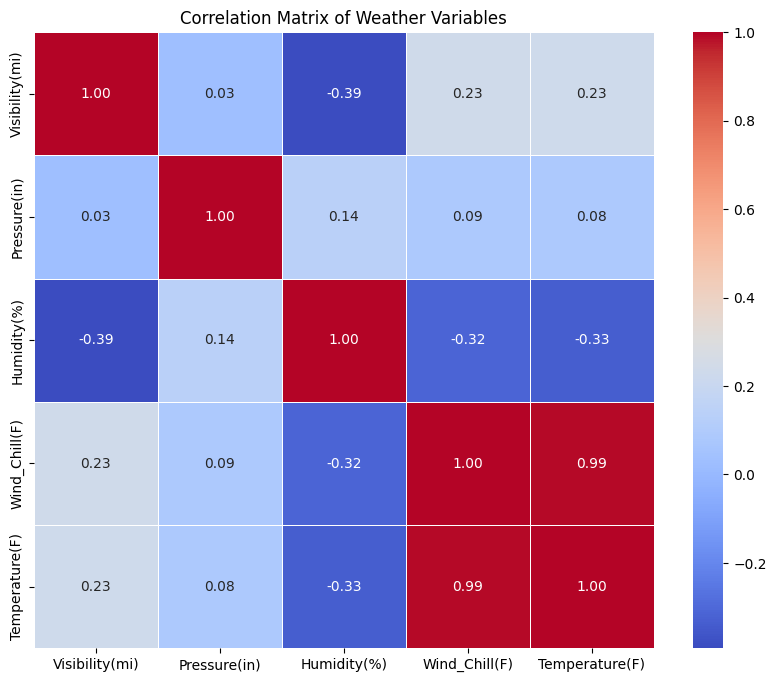

In [11]:

# Select relevant columns and convert them to numeric if necessary
columns_of_interest = ['Visibility(mi)', 'Pressure(in)', 'Humidity(%)', 'Wind_Chill(F)', 'Temperature(F)']
df_filtered = df[columns_of_interest].copy()

# Convert columns to numeric, coercing errors to NaN
df_filtered = df_filtered.apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN values in any of the columns
df_filtered = df_filtered.dropna()

# Compute the correlation matrix
correlation_matrix = df_filtered.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Weather Variables')
plt.show()

<Figure size 1500x1000 with 0 Axes>

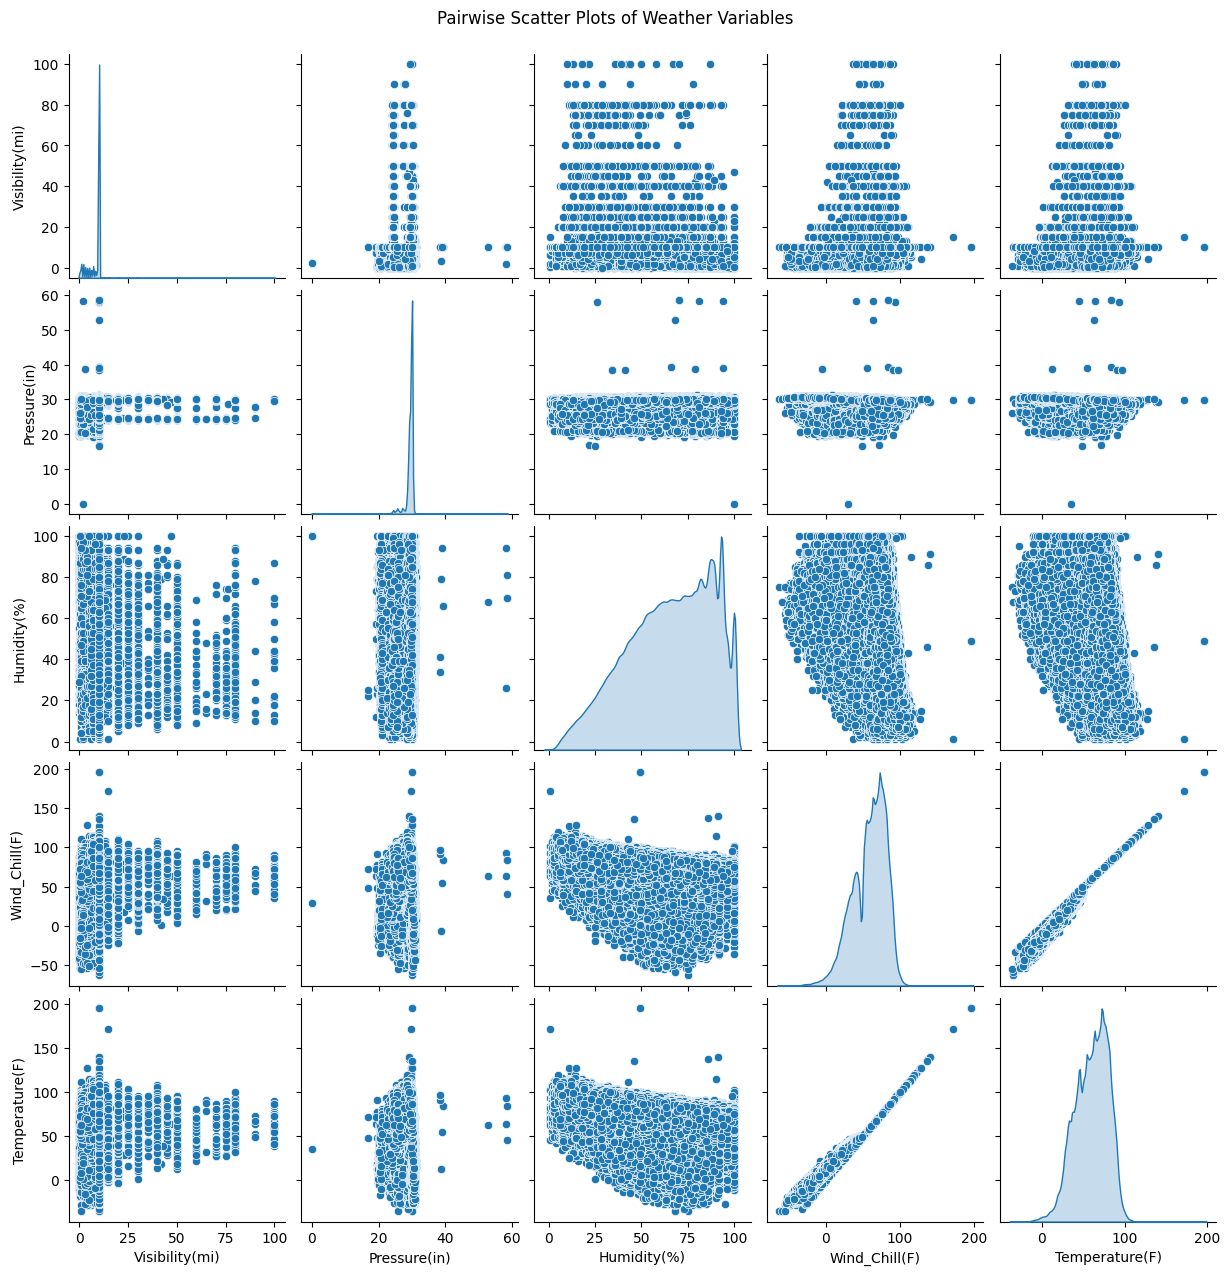

In [12]:
# Plot scatter plots for pairs of variables
plt.figure(figsize=(15, 10))

# Plot all pairs of variables
sns.pairplot(df_filtered, kind='scatter', diag_kind='kde')
plt.suptitle('Pairwise Scatter Plots of Weather Variables', y=1.02)
plt.show()

In [13]:
pip install scikit-learn

In [3]:
pip install statsmodels

In [14]:
# Check for infinite values
infinite_values = df[['Pressure(in)', 'Humidity(%)', 'Wind_Chill(F)', 'Temperature(F)', 'Visibility(mi)']].replace([float('inf'), float('-inf')], pd.NA).isna().sum()
print(infinite_values)

Pressure(in)       70443
Humidity(%)        87204
Wind_Chill(F)     999429
Temperature(F)     82033
Visibility(mi)     88598
dtype: int64


In [15]:
# Replace infinite values with NaN and then handle them
df.replace([float('inf'), float('-inf')], pd.NA, inplace=True)

# Drop rows with NaN values (which include previously infinite values)
df_clean = df.dropna(subset=['Pressure(in)', 'Humidity(%)', 'Wind_Chill(F)', 'Temperature(F)', 'Visibility(mi)'])

In [16]:
import statsmodels.api as sm

# Prepare the features and target variable
X = df_clean[['Pressure(in)', 'Humidity(%)', 'Wind_Chill(F)', 'Temperature(F)']]
y = df_clean['Visibility(mi)']

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Visibility(mi)   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                 1.552e+05
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        07:56:58   Log-Likelihood:            -6.5472e+06
No. Observations:             2848978   AIC:                         1.309e+07
Df Residuals:                 2848973   BIC:                         1.309e+07
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              6.8159      0.039    175.

In [17]:
# Define bins for each variable
pressure_bins = pd.cut(df['Pressure(in)'], bins=5)
humidity_bins = pd.cut(df['Humidity(%)'], bins=5)
wind_chill_bins = pd.cut(df['Wind_Chill(F)'], bins=5)
temperature_bins = pd.cut(df['Temperature(F)'], bins=5)
visibility_bins = pd.cut(df['Visibility(mi)'], bins=5)

# Add these binned columns to the dataframe
df['Pressure_Bin'] = pressure_bins
df['Humidity_Bin'] = humidity_bins
df['Wind_Chill_Bin'] = wind_chill_bins
df['Temperature_Bin'] = temperature_bins
df['Visibility_Bin'] = visibility_bins

In [18]:
# Group by the variables of interest and count the number of accidents
grouped_df = df.groupby(['Pressure(in)', 'Humidity(%)', 'Wind_Chill(F)', 'Temperature(F)', 'Visibility(mi)']).size().reset_index(name='Accident_Count')

# Sort the results to find the combination with the most accidents
sorted_df = grouped_df.sort_values(by='Accident_Count', ascending=False)

# Display the top combinations with the most accidents
print(sorted_df.head())

        Pressure(in)  Humidity(%)  Wind_Chill(F)  Temperature(F)  \
879277         30.00         58.0           82.0            82.0   
912581         30.04         79.0           75.0            75.0   
882442         30.00         88.0           77.0            77.0   
865138         29.98         76.0           80.0            80.0   
832531         29.94         72.0           81.0            81.0   

        Visibility(mi)  Accident_Count  
879277            10.0             113  
912581            10.0             112  
882442            10.0             112  
865138            10.0             111  
832531            10.0             108  


In [19]:
# Group by the binned variables and count the number of accidents
grouped_df = df.groupby(['Pressure_Bin', 'Humidity_Bin', 'Wind_Chill_Bin', 'Temperature_Bin', 'Visibility_Bin']).size().reset_index(name='Accident_Count')

# Sort the results to find the combination with the most accidents
sorted_df = grouped_df.sort_values(by='Accident_Count', ascending=False)

# Display the top combinations with the most accidents
print(sorted_df.head())

          Pressure_Bin   Humidity_Bin Wind_Chill_Bin Temperature_Bin  \
1810  (23.452, 35.178]  (80.2, 100.0]   (29.4, 88.6]    (29.4, 88.6]   
1685  (23.452, 35.178]   (60.4, 80.2]   (29.4, 88.6]    (29.4, 88.6]   
1560  (23.452, 35.178]   (40.6, 60.4]   (29.4, 88.6]    (29.4, 88.6]   
1435  (23.452, 35.178]   (20.8, 40.6]   (29.4, 88.6]    (29.4, 88.6]   
1780  (23.452, 35.178]  (80.2, 100.0]  (-29.8, 29.4]   (-29.8, 29.4]   

     Visibility_Bin  Accident_Count  
1810  (-0.12, 24.0]          737376  
1685  (-0.12, 24.0]          680362  
1560  (-0.12, 24.0]          559709  
1435  (-0.12, 24.0]          314074  
1780  (-0.12, 24.0]           82518  


## Wind_Speed(mph)

In [20]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Pressure_Bin', 'Humidity_Bin',
       'Wind_Chill_Bin', 'Temperature_Bin', 'Visibility_Bin'],
      dtype='object')

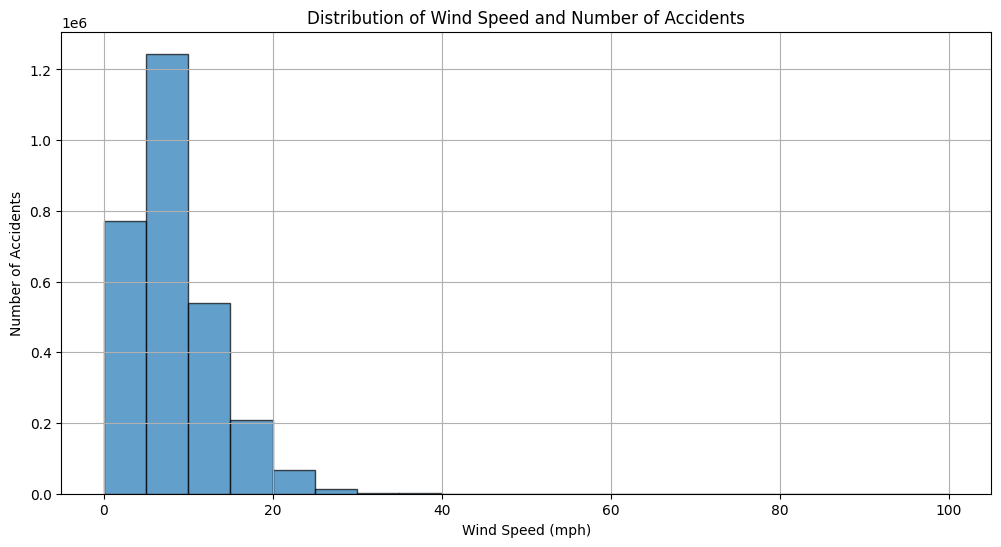

In [21]:
# Plot histogram for 'Wind_Speed(mph)' and accident count
plt.figure(figsize=(12, 6))

# Histogram
plt.hist(df_clean['Wind_Speed(mph)'], bins=range(0, 101, 5), edgecolor='black', alpha=0.7)

plt.title('Distribution of Wind Speed and Number of Accidents')
plt.xlabel('Wind Speed (mph)')
plt.ylabel('Number of Accidents')
plt.grid(True)

plt.show()

In [22]:
df['Wind_Speed(mph)'].describe()

,Wind_Speed(mph)
count,3.578258e+06
mean,7.683843e+00
std,5.462137e+00
min,0.000000e+00
25%,4.600000e+00
50%,7.000000e+00
75%,1.040000e+01
max,1.087000e+03


## Precipitation(in)

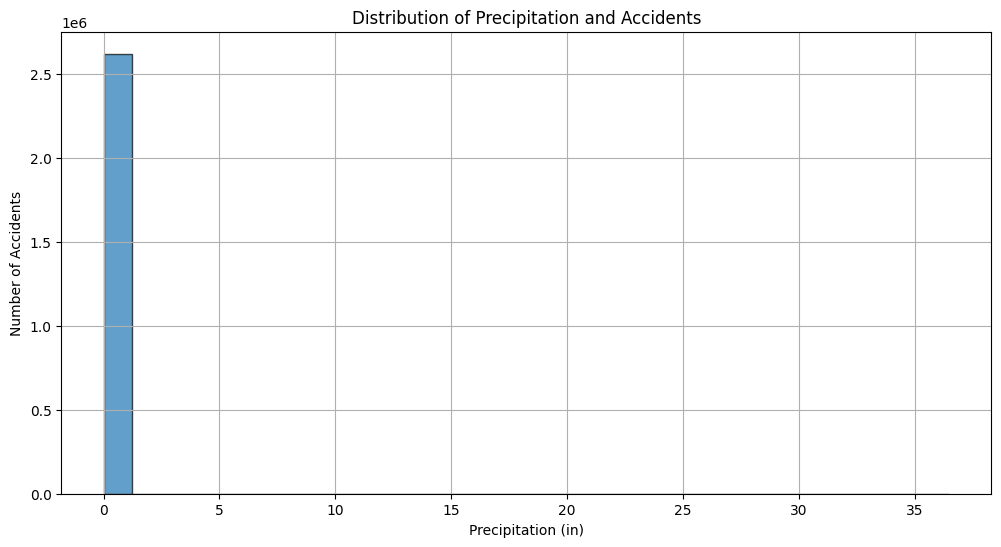

In [23]:
# Plot histogram for 'Precipitation(in)'
plt.figure(figsize=(12, 6))
plt.hist(df_clean['Precipitation(in)'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Precipitation and Accidents')
plt.xlabel('Precipitation (in)')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

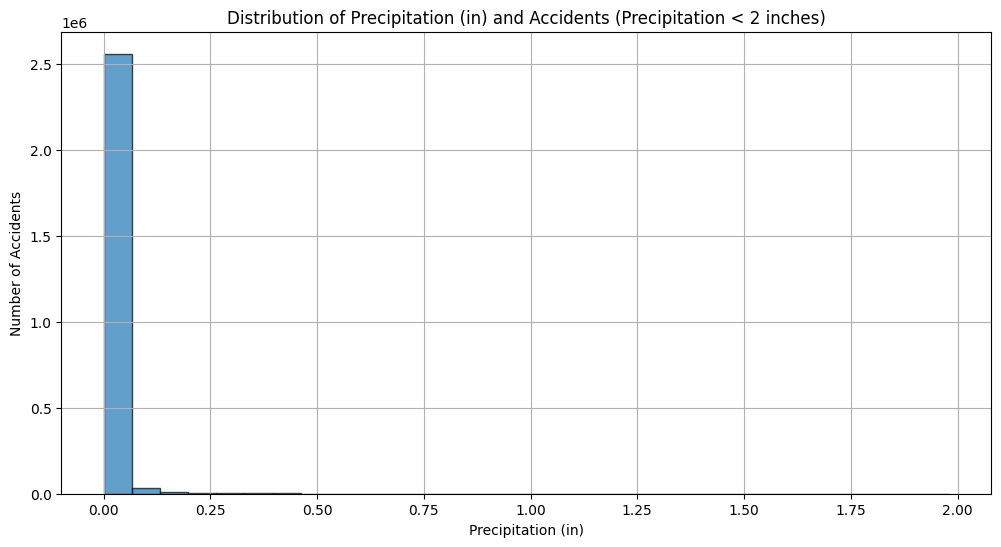

In [24]:
# Filter data for Precipitation(in) < 5
df_filtered = df_clean[df_clean['Precipitation(in)'] < 2]
# Plot histogram for 'Precipitation(in)' with values < 2
plt.figure(figsize=(12, 6))
plt.hist(df_filtered['Precipitation(in)'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Precipitation (in) and Accidents (Precipitation < 2 inches)')
plt.xlabel('Precipitation (in)')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

In [25]:
df['Precipitation(in)'].describe()

,Precipitation(in)
count,2.762074e+06
mean,8.429086e-03
std,1.135636e-01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,3.647000e+01


In [27]:
# we can not interpret accidents by Precipitation

## Weather_Condition

In [28]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Pressure_Bin', 'Humidity_Bin',
       'Wind_Chill_Bin', 'Temperature_Bin', 'Visibility_Bin'],
      dtype='object')

In [29]:
# Count the number of accidents for each weather condition
weather_condition_counts = df['Weather_Condition'].value_counts()

# Convert to DataFrame for easier plotting
weather_condition_df = weather_condition_counts.reset_index()
weather_condition_df.columns = ['Weather_Condition', 'Accident_Count']

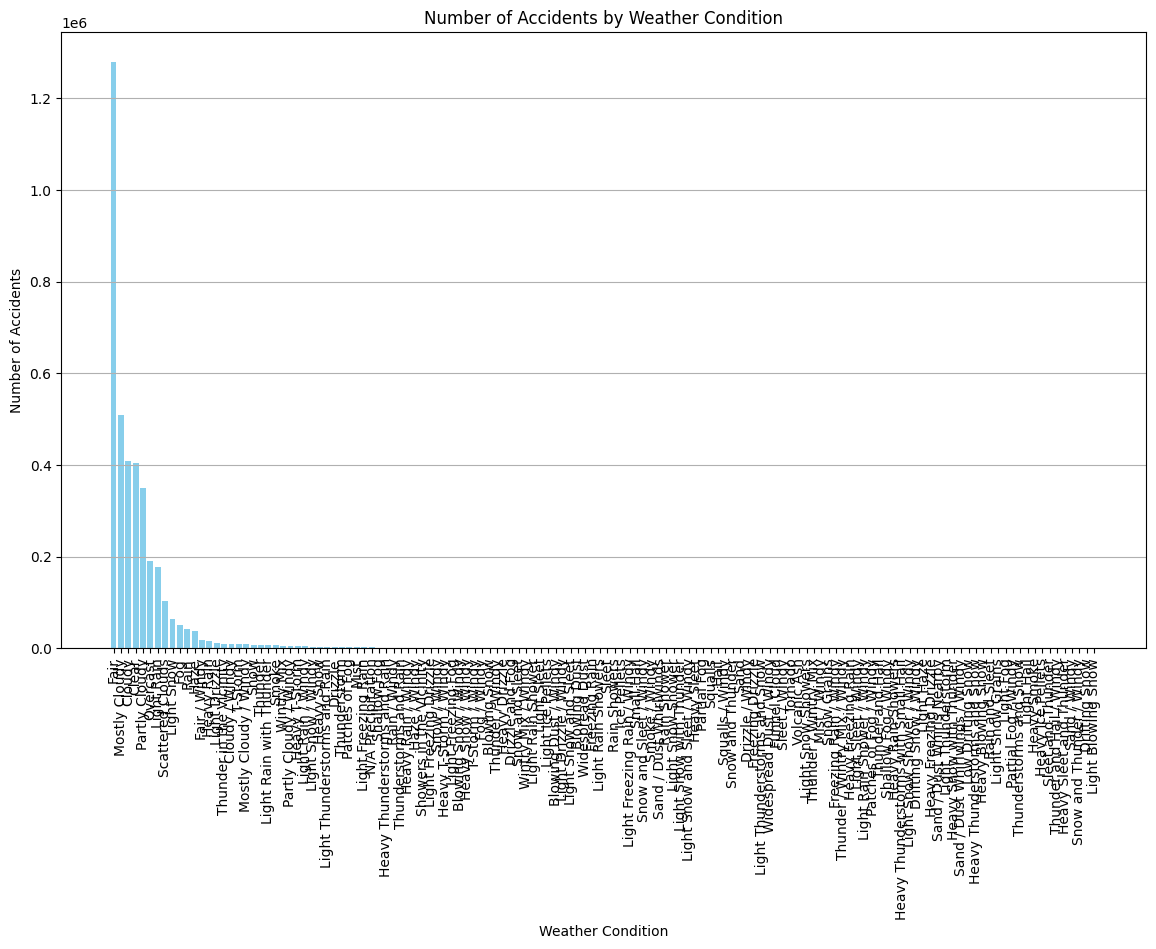

In [30]:
# Plot bar chart
plt.figure(figsize=(14, 8))
plt.bar(weather_condition_df['Weather_Condition'], weather_condition_df['Accident_Count'], color='skyblue')
plt.title('Number of Accidents by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.grid(axis='y')
plt.show()

## Wind_Direction

In [31]:
df['Wind_Direction'].describe()

,Wind_Direction
count,3776669
unique,24
top,CALM
freq,481331


In [32]:
# Display frequency distribution
wind_direction_counts = df['Wind_Direction'].value_counts()
print(wind_direction_counts)

Wind_Direction
CALM        481331
S           209772
SSW         192237
W           191999
WNW         189728
Calm        184715
NW          184419
SW          181977
WSW         176938
SSE         174687
NNW         167009
N           153690
SE          147679
E           139497
ESE         133679
NE          129394
ENE         128967
NNE         127566
VAR         125294
South        88599
West         82281
North        76560
Variable     56777
East         51874
Name: count, dtype: int64


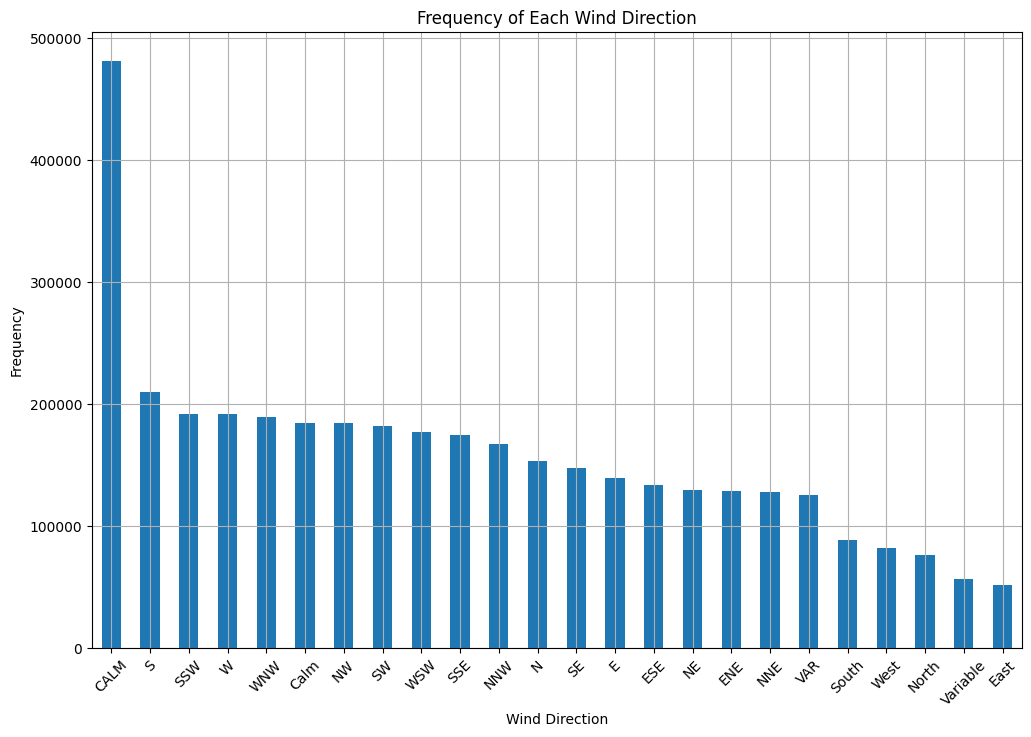

In [33]:
# Bar plot for wind direction frequencies
plt.figure(figsize=(12, 8))
wind_direction_counts.plot(kind='bar')
plt.title('Frequency of Each Wind Direction')
plt.xlabel('Wind Direction')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Weather_Timestamp

In [34]:

df['Weather_Timestamp'].describe()

,Weather_Timestamp
count,3804028
unique,730970
top,2022-03-13 01:53:00
freq,617


## Amenity

In [35]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Pressure_Bin', 'Humidity_Bin',
       'Wind_Chill_Bin', 'Temperature_Bin', 'Visibility_Bin'],
      dtype='object')

In [36]:
df['Amenity'].describe()

,Amenity
count,3864197
unique,2
top,False
freq,3816069


## Traffic_Signal

In [37]:
df['Traffic_Signal'].describe()

,Traffic_Signal
count,3864197
unique,2
top,False
freq,3293228


## Roundabout

In [38]:
df['Roundabout'].describe()

,Roundabout
count,3864197
unique,2
top,False
freq,3864060


## Summary Amenity, Traffic_Signal, Roundabout
we remarque that the three variables are Imbalanced.

## Astronomical_Twilight, Nautical_Twilight, Civil_Twilight

In [39]:

df['Astronomical_Twilight'].describe()

,Astronomical_Twilight
count,3852590
unique,2
top,Day
freq,3189213


In [40]:
df['Nautical_Twilight'].describe()

,Nautical_Twilight
count,3852590
unique,2
top,Day
freq,3038199


In [41]:
df['Civil_Twilight'].describe()

,Civil_Twilight
count,3852590
unique,2
top,Day
freq,2848063
